# Diagnostic Énergie · Climat · Forêts — Togo

**Analyse intégrée : électrification, biomasse domestique, bilan carbone, climatologie et cartographie des aires protégées**

---

Ce notebook consolide en une seule analyse reproductible les travaux menés sur l'archive `data/` (indicateurs Banque mondiale, inventaire national des émissions de GES, service météorologique national, cadastre des forêts classées). Il répond à cinq objectifs analytiques, chacun doté de **filtres interactifs** pour explorer les données, et se conclut par une cartographie interactive et une analyse de **centralité** des forêts classées destinée à prioriser les investissements.

| # | Analyse | Question |
|---|---|---|
| 1 | **Électrification** | Fracture ville/campagne et fiabilité du réseau |
| 2 | **Biomasse & déforestation** | Dépendance au bois-énergie et recul du couvert forestier |
| 3 | **Bilan carbone** | Poids du secteur énergie face aux autres secteurs (AFAT, industrie, déchets) |
| 4 | **Climatologie** | Évolution des températures sur 10 stations, du Sud au Nord |
| 5 | **Cartographie & centralité** | Localisation des 53 forêts classées, réseau de proximité et priorisation des investissements |

**Comment utiliser ce notebook :** exécutez les cellules dans l'ordre (`Kernel → Restart & Run All`). Les cellules marquées **🎛️ Filtre interactif** affichent des widgets (sliders, menus, cases à cocher) qui remettent à jour le graphique juste en dessous — elles nécessitent un noyau Jupyter actif (Jupyter Notebook/Lab ou VS Code), pas un simple rendu HTML statique.

---

**Note d'audit (version révisée) :** ce notebook reprend intégralement l'analyse originale — aucune lecture correcte n'a été supprimée — et y ajoute : audit systématique des données (sources, unités, limites), actualisation documentée de certains indicateurs, correction d'une erreur d'unité sur le bilan GES (Gg confondu avec Mt), reformulation du décompte des forêts classées (à ne pas lire comme l'inventaire national des aires protégées), test de robustesse du graphe de centralité, statistiques de tendance climatique formelles (Mann-Kendall, pente de Sen), un volet Machine Learning avec projections 2030 évaluées par validation croisée temporelle, un indice de priorité territoriale, un tableau de bord de KPI stratégiques et un audit qualité final noté.

**Table des matières (numérotation de ce notebook) :**

| # | Section |
|---|---|
| 1 | Introduction |
| 2 | Problématique |
| 3 | Qualité et préparation des données |
| 4 | Sources et données (audit) |
| 5 | Accès à l'électricité |
| 6 | Énergie et cuisson des ménages (avec recul du couvert forestier) |
| 7 | Émissions de gaz à effet de serre |
| 8 | Analyse climatique |
| 9 | Forêts et aires protégées |
| 10 | Analyse par graphes et centralité |
| 11 | Analyse géospatiale (carte interactive) |
| 12 | Interactions énergie → forêt → climat |
| 13 | Machine Learning |
| 14 | Projection 2030 et objectifs officiels |
| 15 | KPI stratégiques — tableau de bord |
| 16 | Indice de priorité territoriale |
| 17 | Recommandations opérationnelles |
| 18 | Limites et précautions d'interprétation |
| 19 | Sources et références |
| 20 | Conclusion et audit qualité final |

*Note d'ordonnancement : par rapport à la trame de 20 sections demandée, deux permutations mineures ont été faites pour respecter l'ordre réel de dépendance des calculs (aucune section n'utilise une variable calculée plus loin qu'elle dans le notebook) : (1) « Qualité et préparation des données » (config, imports) précède « Sources et données (audit) » puisque l'audit affiche des données déjà chargées ; (2) les blocs « Forêts », « Centralité » et « Analyse géospatiale » sont placés après le bilan GES et la climatologie, car la carte interactive (§11) affiche des marqueurs climatiques calculés au §8 et des scores de centralité calculés au §10. Une table de correspondance est fournie en Section 19 (Sources et références).*


## 2. Problématique

Le Togo affiche simultanément : une fracture électrique ville/campagne persistante, une dépendance quasi générale des ménages au bois-énergie, un recul du couvert forestier, et un bilan de gaz à effet de serre dominé par le secteur agriculture-foresterie plutôt que par l'énergie. Ces quatre constats sont a priori disjoints dans les publications sectorielles habituelles.

**Question centrale de ce notebook :** dans quelle mesure ces quatre dimensions — électrification, biomasse domestique, forêts, climat — sont-elles liées dans les données disponibles, et quelles priorités territoriales et technologiques cela suggère-t-il à l'horizon 2030 ?

Cette question est traitée avec les précautions suivantes, appliquées de bout en bout :
- une corrélation observée entre deux séries n'est **jamais** présentée comme une relation causale ;
- toute donnée ancienne conserve sa date affichée à côté de la valeur ;
- toute projection (2030) est visuellement et textuellement distinguée d'une donnée observée ;
- toute conclusion reste bornée à ce que les données fournies permettent réellement d'établir.

## 3. Qualité et préparation des données

Configuration, imports et fonctions réutilisables (`load_data`, `clean_data`, `validate_data`, `calculate_kpis`, `calculate_centrality`, `build_forecast`, `plot_trend`), puis chargement typé des six jeux de données utiles avec contrôles automatiques.

In [1]:
import warnings, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from shapely import wkt
import networkx as nx
from scipy.spatial import cKDTree
from scipy import stats as scistats
import pymannkendall as pmk

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import folium
from folium.plugins import HeatMap, Fullscreen, MiniMap

import ipywidgets as widgets
from ipywidgets import interact, interactive_output, HBox, VBox, Layout
from IPython.display import display, HTML, clear_output

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.grid': True,
    'grid.color': '#dddddd',
    'grid.linewidth': 0.6,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Palette institutionnelle sobre (partagée par tous les graphiques et par la carte)
C_PRIMARY   = '#1B4332'   # vert forêt
C_SECONDARY = '#2D6A4F'
C_ACCENT    = '#D68C45'   # ocre (énergie / biomasse)
C_ALERT     = '#B02E0C'   # rouge alerte
C_BLUE      = '#1B5E8C'   # bleu (électricité / froid)
C_PURPLE    = '#7B4B94'   # violet (centralité)
C_GREY      = '#6C757D'

REGION_COLORS = {'Maritime': C_BLUE, 'Plateaux': C_SECONDARY, 'Centrale': C_ACCENT,
                  'Kara': C_PURPLE, 'Savanes': C_ALERT}

DATA_DIR = Path('data')

# --- Fonctions réutilisables (Section 24 de l'audit : qualité du code) ---

def load_data(path, **kwargs):
    """Charge un CSV avec des paramètres de lecture homogènes et lève une erreur explicite si le fichier est absent."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable : {path}")
    return pd.read_csv(path, **kwargs)


def clean_data(df, subset_dropna=None, dedup_subset=None):
    """Nettoyage standard : retire les lignes sans valeur sur `subset_dropna`, dé-doublonne sur `dedup_subset`."""
    out = df.copy()
    n0 = len(out)
    if subset_dropna:
        out = out.dropna(subset=subset_dropna)
    if dedup_subset:
        out = out.drop_duplicates(subset=dedup_subset)
    else:
        out = out.drop_duplicates()
    return out.reset_index(drop=True)


def validate_data(df, name, year_col=None, value_col=None, value_range=None):
    """Contrôles automatiques (Section 25 de l'audit) : lignes>0, pas de doublons, années valides, valeurs dans un intervalle physique plausible."""
    problems = []
    if df.shape[0] == 0:
        problems.append("dataframe vide")
    if df.duplicated().sum() > 0:
        problems.append(f"{df.duplicated().sum()} doublon(s) exact(s)")
    if year_col is not None and year_col in df.columns:
        if df[year_col].isna().any():
            problems.append(f"années manquantes dans '{year_col}'")
        if (df[year_col] < 1900).any() or (df[year_col] > 2035).any():
            problems.append(f"année hors plage plausible dans '{year_col}'")
    if value_col is not None and value_range is not None and value_col in df.columns:
        vmin, vmax = value_range
        out_of_range = df[(df[value_col] < vmin) | (df[value_col] > vmax)]
        if len(out_of_range):
            problems.append(f"{len(out_of_range)} valeur(s) hors intervalle plausible [{vmin}, {vmax}] dans '{value_col}'")
    status = "✅ OK" if not problems else "⚠️ " + " ; ".join(problems)
    print(f"[validate_data] {name:45s} -> {status}")
    return len(problems) == 0


def calculate_kpis(series, label, unit=""):
    """Retourne un petit dict KPI standard (première/dernière valeur, delta, taux annuel moyen) pour une série (Year, Value)."""
    s = series.dropna(subset=["Value"]).sort_values("Year")
    if len(s) < 2:
        return {"indicateur": label, "unite": unit, "n": len(s)}
    v0, v1 = s["Value"].iloc[0], s["Value"].iloc[-1]
    y0, y1 = int(s["Year"].iloc[0]), int(s["Year"].iloc[-1])
    duree = max(y1 - y0, 1)
    return {
        "indicateur": label, "valeur_debut": round(v0, 2), "annee_debut": y0,
        "valeur_fin": round(v1, 2), "annee_fin": y1, "unite": unit,
        "delta_absolu": round(v1 - v0, 2), "taux_annuel_moyen": round((v1 - v0) / duree, 3),
    }


def calculate_centrality(forets_df, coords_m, k_voisins):
    """Construit le graphe de proximité à k voisins et renvoie les trois indices de centralité (degré, intermédiarité, proximité)."""
    tree_ = cKDTree(coords_m)
    dist_, idx_ = tree_.query(coords_m, k=k_voisins + 1)
    Gk = nx.Graph()
    for i in range(len(forets_df)):
        Gk.add_node(i)
    for i in range(len(forets_df)):
        for pos in range(1, k_voisins + 1):
            j = int(idx_[i, pos]); d_km = dist_[i, pos] / 1000
            if d_km > 0:
                Gk.add_edge(i, j, distance_km=d_km)
    deg = nx.degree_centrality(Gk)
    btw = nx.betweenness_centrality(Gk, weight='distance_km', normalized=True)
    clo = nx.closeness_centrality(Gk, distance='distance_km')
    return Gk, deg, btw, clo


def build_forecast(annees, valeurs, annee_cible=2030, borne=None, test_frac=0.2, min_test=3):
    """Compare 3 modèles (régression linéaire, Random Forest, Gradient Boosting) par validation
    temporelle 'walk-forward' (entraînement sur le passé, test sur les dernières années disponibles),
    puis projette `annee_cible` avec chaque modèle. `borne` = (min, max) pour brider une projection
    physiquement impossible (ex. un taux d'accès ne peut pas dépasser 100%).
    Retourne (tableau_comparatif, nom_du_meilleur_modele_par_RMSE)."""
    X = np.asarray(annees, dtype=float).reshape(-1, 1)
    y = np.asarray(valeurs, dtype=float)
    n = len(y)
    if n < 8:
        return None, None
    n_test = max(min_test, int(round(n * test_frac)))
    n_train = n - n_test
    Xtr, Xte = X[:n_train], X[n_train:]
    ytr, yte = y[:n_train], y[n_train:]

    modeles = {
        'Régression linéaire': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42, max_depth=4),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=200, max_depth=2, learning_rate=0.05),
    }
    lignes = []
    for nom, modele in modeles.items():
        modele.fit(Xtr, ytr)
        pred_test = modele.predict(Xte)
        mae = mean_absolute_error(yte, pred_test)
        rmse = np.sqrt(mean_squared_error(yte, pred_test))
        r2 = r2_score(yte, pred_test) if n_test >= 2 else np.nan
        modele.fit(X, y)  # ré-entraînement sur l'intégralité de la série pour la projection finale
        pred_brute = float(modele.predict([[annee_cible]])[0])
        pred_bornee = float(np.clip(pred_brute, borne[0], borne[1])) if borne else pred_brute
        lignes.append({
            'Modèle': nom, 'MAE (validation)': round(mae, 3), 'RMSE (validation)': round(rmse, 3),
            'R² (validation)': round(r2, 3), f'Projection brute {annee_cible}': round(pred_brute, 2),
            f'Projection retenue {annee_cible}': round(pred_bornee, 2),
        })
    tableau = pd.DataFrame(lignes)
    meilleur = tableau.sort_values('RMSE (validation)').iloc[0]['Modèle']
    return tableau, meilleur


def plot_trend(ax, x, y, color, label, unit=''):
    """Trace une série + sa régression linéaire (pente, IC95%, R², p-value) annotée — utilitaire générique."""
    ax.plot(x, y, color=color, lw=2, marker='o', ms=4, label=label)
    if len(x) >= 4:
        slope, intercept, r, p, se = scistats.linregress(x, y)
        ax.plot(x, intercept + slope * np.asarray(x), color=color, ls='--', lw=1.2, alpha=0.7)
        return {'pente': slope, 'se': se, 'r2': r**2, 'p_value': p}
    return None


In [2]:
# --- Inventaire des fichiers sources (audit qualité) ---
csv_paths = sorted(DATA_DIR.glob('*.csv'))
inventory = []
for p in csv_paths:
    tmp = pd.read_csv(p, low_memory=False, encoding='utf-8-sig', on_bad_lines='skip')
    inventory.append({
        'fichier': p.name,
        'lignes': tmp.shape[0],
        'colonnes': tmp.shape[1],
        'valeurs_manquantes_%': round(tmp.isna().mean().mean() * 100, 1),
        'doublons_exacts': int(tmp.duplicated().sum()),
    })
inventory_df = pd.DataFrame(inventory).sort_values('lignes', ascending=False).reset_index(drop=True)
display(inventory_df)

print("\nNote : « zones-protegees-forets-classees.csv » est un DICTIONNAIRE DE DONNÉES (description des champs),")
print("pas un jeu de données — il n'est pas utilisé dans les analyses ci-dessous. La géométrie des 53 forêts")
print("provient de « file-zones-protegees-forets-classees-23-12-2024...csv ».")

,fichier,lignes,colonnes,valeurs_manquantes_%,doublons_exacts
0,indicators-tgo.csv,81447,6,0.0,17923
1,observationdata-yvlucze.csv,1680,6,0.0,0
2,zones-protegees-forets-classees.csv,77,5,9.1,0
3,emissions-de-dioxyde-de-carbone-co2-du-secteur...,64,8,27.1,0
4,energies-renouvelables-combustibles-et-dechets...,64,8,28.9,0
5,file-zones-protegees-forets-classees-23-12-202...,53,9,0.0,0
6,observationdata-xorttne.csv,20,6,0.0,0



Note : « zones-protegees-forets-classees.csv » est un DICTIONNAIRE DE DONNÉES (description des champs),
pas un jeu de données — il n'est pas utilisé dans les analyses ci-dessous. La géométrie des 53 forêts
provient de « file-zones-protegees-forets-classees-23-12-2024...csv ».


**Lecture qualité :** sept fichiers hétérogènes (de 20 à plus de 81 000 lignes), aux granularités et périodes différentes. Le taux de valeurs manquantes élevé sur `indicators-tgo.csv` s'explique par sa structure "grand catalogue" : plus de 3 400 indicateurs Banque mondiale, dont l'immense majorité n'a que quelques années renseignées pour le Togo — on ne travaillera donc qu'avec un sous-ensemble ciblé (électricité, cuisson, forêts). Les autres fichiers sont des extractions déjà focalisées et quasi complètes.

In [3]:
# --- Chargement typé des 6 jeux de données utiles ---

# 1) Indicateurs Banque mondiale (WDI) — grand catalogue, on filtrera par nom d'indicateur
indicators = pd.read_csv(DATA_DIR / 'indicators-tgo.csv', skiprows=[1])
n_before = len(indicators)
indicators = indicators.drop_duplicates()

def get_series(indicator_name, df=indicators):
    '''Extrait une série temporelle propre (Year, Value) pour un indicateur donné.'''
    s = (df[df['Indicator Name'] == indicator_name]
         .dropna(subset=['Value'])
         .drop_duplicates(subset=['Year'])
         .sort_values('Year'))
    return s[['Year', 'Value']].reset_index(drop=True)

# 2) Séries dédiées CO2 énergie & renouvelables/biomasse
co2_energie   = pd.read_csv(DATA_DIR / 'emissions-de-dioxyde-de-carbone-co2-du-secteur-de-lenergie-mt-co2e-.csv')
renouvelables = pd.read_csv(DATA_DIR / 'energies-renouvelables-combustibles-et-dechets-de-lenergie-totale-.csv')

# 3) Bilan GES sectoriel (inventaire national, dernière année disponible)
ges_sectoriel = pd.read_csv(DATA_DIR / 'observationdata-xorttne.csv')
# ⚠️ CORRECTION D'UNITÉ (audit) : la colonne 'Unit' du fichier source vaut 'Gg' (gigagrammes = kilotonnes),
# PAS 'Mt' (mégatonnes) comme le laissait entendre une version précédente de ce notebook. 1 Gg = 0.001 Mt.
assert set(ges_sectoriel['Unit'].unique()) == {'Gg'}, "Unité inattendue dans le fichier GES sectoriel"
ges_sectoriel['Value_Gg'] = ges_sectoriel['Value']
ges_sectoriel['Value'] = ges_sectoriel['Value_Gg'] / 1000.0   # conversion Gg -> Mt CO2e, utilisée dans tout le notebook

# 4) Températures mensuelles, 10 villes
temperatures = pd.read_csv(DATA_DIR / 'observationdata-yvlucze.csv')
temperatures['Year']  = temperatures['Date'].str.extract(r'(\d{4})').astype(int)
temperatures['Month'] = temperatures['Date'].str.extract(r'M(\d+)').astype(int)

# 5) Forêts classées / zones protégées (géométries WKT -> GeoDataFrame)
forets = pd.read_csv(DATA_DIR / 'file-zones-protegees-forets-classees-23-12-2024-09-53-17.csv')
forets['geometry'] = forets['geometry'].apply(wkt.loads)
forets = gpd.GeoDataFrame(forets, geometry='geometry', crs='EPSG:4326')

print(f"Doublons exacts retirés de indicators-tgo.csv : {n_before - len(indicators)}")
print(f"Indicateurs WDI disponibles pour le Togo       : {indicators['Indicator Name'].nunique():,}")
print(f"Températures                                   : {temperatures['villes'].nunique()} villes, "
      f"{temperatures['Year'].min()}-{temperatures['Year'].max()}")
print(f"Forêts classées / zones protégées              : {len(forets)} entités géoréférencées")

Doublons exacts retirés de indicators-tgo.csv : 17923
Indicateurs WDI disponibles pour le Togo       : 3,437
Températures                                   : 10 villes, 2013-2019
Forêts classées / zones protégées              : 53 entités géoréférencées


In [4]:
# --- Contrôles automatiques post-chargement (Section 25 de l'audit) ---
validate_data(indicators, "indicators-tgo.csv", year_col='Year')
validate_data(co2_energie.dropna(subset=['value']), "CO2 secteur énergie", year_col='date', value_col='value', value_range=(0, 50))
validate_data(renouvelables.dropna(subset=['value']), "Renouvelables + biomasse (% énergie)", year_col='date', value_col='value', value_range=(0, 100))
validate_data(ges_sectoriel, "GES sectoriel (converti en Mt)", value_col='Value', value_range=(0, 100))
validate_data(temperatures, "Températures (10 villes)", year_col='Year', value_col='Value', value_range=(-5, 55))
validate_data(pd.DataFrame(forets.drop(columns='geometry')), "Forêts classées (cadastre)")

# Contrôle de cohérence sectorielle (Section 15 : somme des secteurs = total national)
_tot_check = ges_sectoriel[(ges_sectoriel.secteur == 'Total') & (ges_sectoriel.type == 'Total')]['Value'].values[0]
_sum_check = ges_sectoriel[(ges_sectoriel.type == 'Total') & (ges_sectoriel.secteur != 'Total')]['Value'].sum()
assert abs(_tot_check - _sum_check) < 0.01, "Incohérence : la somme des émissions sectorielles ne correspond pas au total national déclaré"
print(f"[validate_data] Cohérence sectorielle GES : somme des 4 secteurs = {_sum_check:.2f} Mt CO2e = total déclaré ({_tot_check:.2f} Mt CO2e) -> ✅ OK")


[validate_data] indicators-tgo.csv                            -> ✅ OK
[validate_data] CO2 secteur énergie                           -> ✅ OK
[validate_data] Renouvelables + biomasse (% énergie)          -> ✅ OK
[validate_data] GES sectoriel (converti en Mt)                -> ✅ OK
[validate_data] Températures (10 villes)                      -> ✅ OK
[validate_data] Forêts classées (cadastre)                    -> ✅ OK
[validate_data] Cohérence sectorielle GES : somme des 4 secteurs = 40.84 Mt CO2e = total déclaré (40.84 Mt CO2e) -> ✅ OK


## 4. Sources et données

Cette section audite chacun des sept fichiers fournis avant toute analyse : source, période, unité, valeurs manquantes, doublons et limites méthodologiques.

In [5]:
# Dépendances : décommentez si l'environnement ne les a pas déjà.
# %pip install -q geopandas shapely folium networkx ipywidgets

In [6]:
# --- Tableau d'audit détaillé (Section 3 du plan d'audit) ---
audit_rows = [
    {"Dataset": "indicators-tgo.csv", "Source": "Banque mondiale — World Development Indicators (WDI)",
     "Période": "1960-2023 (catalogue)", "Unité": "variable selon indicateur",
     "Dernière année exploitée": "2022 (électricité, cuisson propre) / 2017 (combustible principal) / 2021 (forêt) / 2016 (fiabilité réseau)",
     "Limites": "Catalogue générique de >3 400 indicateurs ; seul un sous-ensemble ciblé est exploité ici."},
    {"Dataset": "emissions-...-secteur-de-lenergie-mt-co2e-.csv", "Source": "Banque mondiale / Climate Watch (CO2 secteur énergie)",
     "Période": "1960-2023", "Unité": "Mt CO2e",
     "Dernière année exploitée": "2022", "Limites": "Valeurs manquantes en fin de série (2023) ; NaN écartés."},
    {"Dataset": "energies-renouvelables-...-energie-totale-.csv", "Source": "Banque mondiale (part renouvelables + combustibles/déchets dans l'énergie totale)",
     "Période": "1960-2023", "Unité": "% de l'énergie totale",
     "Dernière année exploitée": "2021", "Limites": "Agrège biomasse traditionnelle et renouvelables modernes : ne pas lire comme un indicateur de transition énergétique propre."},
    {"Dataset": "observationdata-xorttne.csv (GES sectoriel)", "Source": "Inventaire national des émissions de GES (dernier inventaire disponible)",
     "Période": "Année unique", "Unité": "Gg CO2e (⚠️ PAS Mt — voir correction Section 3, détaillée Section 7)",
     "Dernière année exploitée": "2018", "Limites": "Un seul point temporel : aucune tendance intersectorielle calculable."},
    {"Dataset": "observationdata-yvlucze.csv (températures)", "Source": "Service météorologique national du Togo, 10 stations",
     "Période": "2013-M01 à 2019-M09", "Unité": "°C",
     "Dernière année exploitée": "2019 (partielle)", "Limites": "Fenêtre courte (~7 ans) : les tendances doivent être lues comme un signal indicatif, pas une normale climatique (l'OMM recommande des séries ≥30 ans)."},
    {"Dataset": "file-zones-protegees-forets-classees-...csv", "Source": "Cadastre national des forêts classées (portail géospatial togolais), extraction du 23/12/2024",
     "Période": "Dates de création hétérogènes (1884 → aujourd'hui, dont dates non documentées)", "Unité": "géométries (km² recalculés en projection métrique)",
     "Dernière année exploitée": "Extraction 2024-12-23",
     "Limites": "53 POLYGONES DE FORÊTS CLASSÉES uniquement : sous-ensemble du dispositif national d'aires protégées, pas son inventaire exhaustif (voir Section 9)."},
    {"Dataset": "zones-protegees-forets-classees.csv", "Source": "Dictionnaire de données du cadastre ci-dessus",
     "Période": "N/A", "Unité": "N/A", "Dernière année exploitée": "N/A",
     "Limites": "Description des champs, pas un jeu de données : non utilisé dans les analyses."},
]
audit_df = pd.DataFrame(audit_rows)
display(audit_df.style.hide(axis='index').set_properties(**{'text-align': 'left', 'white-space': 'normal'}))


Dataset,Source,Période,Unité,Dernière année exploitée,Limites
indicators-tgo.csv,Banque mondiale — World Development Indicators (WDI),1960-2023 (catalogue),variable selon indicateur,"2022 (électricité, cuisson propre) / 2017 (combustible principal) / 2021 (forêt) / 2016 (fiabilité réseau)",Catalogue générique de >3 400 indicateurs ; seul un sous-ensemble ciblé est exploité ici.
emissions-...-secteur-de-lenergie-mt-co2e-.csv,Banque mondiale / Climate Watch (CO2 secteur énergie),1960-2023,Mt CO2e,2022,Valeurs manquantes en fin de série (2023) ; NaN écartés.
energies-renouvelables-...-energie-totale-.csv,Banque mondiale (part renouvelables + combustibles/déchets dans l'énergie totale),1960-2023,% de l'énergie totale,2021,Agrège biomasse traditionnelle et renouvelables modernes : ne pas lire comme un indicateur de transition énergétique propre.
observationdata-xorttne.csv (GES sectoriel),Inventaire national des émissions de GES (dernier inventaire disponible),Année unique,"Gg CO2e (⚠️ PAS Mt — voir correction Section 3, détaillée Section 7)",2018,Un seul point temporel : aucune tendance intersectorielle calculable.
observationdata-yvlucze.csv (températures),"Service météorologique national du Togo, 10 stations",2013-M01 à 2019-M09,°C,2019 (partielle),"Fenêtre courte (~7 ans) : les tendances doivent être lues comme un signal indicatif, pas une normale climatique (l'OMM recommande des séries ≥30 ans)."
file-zones-protegees-forets-classees-...csv,"Cadastre national des forêts classées (portail géospatial togolais), extraction du 23/12/2024","Dates de création hétérogènes (1884 → aujourd'hui, dont dates non documentées)",géométries (km² recalculés en projection métrique),Extraction 2024-12-23,"53 POLYGONES DE FORÊTS CLASSÉES uniquement : sous-ensemble du dispositif national d'aires protégées, pas son inventaire exhaustif (voir Section 9)."
zones-protegees-forets-classees.csv,Dictionnaire de données du cadastre ci-dessus,N/A,N/A,N/A,"Description des champs, pas un jeu de données : non utilisé dans les analyses."


**Lecture d'audit :** aucun fichier ne couvre la même période ni la même unité — c'est la contrainte structurante de tout le notebook. Deux points appellent une vigilance particulière et sont traités explicitement plus loin : l'unité du bilan GES sectoriel (Gg, pas Mt — corrigé Section 3, détaillé Section 7) et le périmètre du cadastre forestier (53 polygones de forêts classées, pas l'ensemble des aires protégées du Togo — Section 9).

---
## 5. Accès à l'électricité — fracture ville/campagne et fiabilité du réseau

**Question :** comment l'accès à l'électricité a-t-il évolué en ville et à la campagne, et le réseau est-il fiable ?

In [7]:
elec_rural = get_series('Access to electricity, rural (% of rural population)')
elec_urban = get_series('Access to electricity, urban (% of urban population)')
elec_total = get_series('Access to electricity (% of population)')

annee_min, annee_max = int(elec_urban.Year.min()), int(elec_urban.Year.max())

def plot_electrification(annees=(annee_min, annee_max), afficher_national=True):
    y0, y1 = annees
    eu = elec_urban[(elec_urban.Year >= y0) & (elec_urban.Year <= y1)]
    er = elec_rural[(elec_rural.Year >= y0) & (elec_rural.Year <= y1)]
    et = elec_total[(elec_total.Year >= y0) & (elec_total.Year <= y1)]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(eu.Year, eu.Value, color=C_BLUE, lw=2.5, marker='o', ms=4, label='Urbain')
    ax.plot(er.Year, er.Value, color=C_ACCENT, lw=2.5, marker='o', ms=4, label='Rural')
    if afficher_national and len(et):
        ax.plot(et.Year, et.Value, color=C_GREY, lw=1.5, ls='--', label='National')
    if len(eu) and len(er):
        common = np.linspace(max(eu.Year.min(), er.Year.min()), min(eu.Year.max(), er.Year.max()), 100)
        ax.fill_between(common, np.interp(common, er.Year, er.Value), np.interp(common, eu.Year, eu.Value),
                         color=C_ALERT, alpha=0.08)
    ax.set_title(f"Accès à l'électricité — Togo, {y0}-{y1}")
    ax.set_ylabel('% de la population'); ax.set_ylim(0, 100)
    ax.legend(frameon=False)
    plt.tight_layout(); plt.savefig('figures/01_electrification_ville_campagne.png', dpi=150); plt.show()

    if len(er) and len(eu):
        gap_debut = eu.Value.iloc[0] - er.Value.iloc[0]
        gap_fin   = eu.Value.iloc[-1] - er.Value.iloc[-1]
        mult_rural = er.Value.iloc[-1] / er.Value.iloc[0] if er.Value.iloc[0] else np.nan
        print(f"Accès rural  : {er.Value.iloc[0]:.1f}% ({int(er.Year.iloc[0])}) -> {er.Value.iloc[-1]:.1f}% ({int(er.Year.iloc[-1])})  [x{mult_rural:.1f}]")
        print(f"Accès urbain : {eu.Value.iloc[0]:.1f}% ({int(eu.Year.iloc[0])}) -> {eu.Value.iloc[-1]:.1f}% ({int(eu.Year.iloc[-1])})")
        print(f"Écart ville-campagne : {gap_debut:.1f} pts -> {gap_fin:.1f} pts")

print("🎛️ Filtre interactif — période et affichage de la moyenne nationale")
interact(plot_electrification,
         annees=widgets.IntRangeSlider(value=[annee_min, annee_max], min=annee_min, max=annee_max, step=1,
                                        description='Période', continuous_update=False, layout=Layout(width='480px')),
         afficher_national=widgets.Checkbox(value=True, description='Afficher le national'));

🎛️ Filtre interactif — période et affichage de la moyenne nationale


interactive(children=(IntRangeSlider(value=(1998, 2022), continuous_update=False, description='Période', layou…

**Lecture :** l'accès rural a été multiplié par plusieurs unités en deux décennies, mais l'accès urbain a progressé plus vite en valeur absolue. **L'écart en points de pourcentage s'est donc creusé** : la fracture ville/campagne se réduit en relatif mais **s'aggrave en absolu**. Un ménage rural togolais sur quatre seulement a accès au réseau en 2022, contre 96,5 % en ville. Utilisez le filtre ci-dessus pour isoler une sous-période (ex. 2010-2022, phase d'accélération rurale).

In [8]:
# --- KPI 1 à 5 (Section 4 de l'audit) ---
kpi_rows = [
    calculate_kpis(elec_total, "KPI 1 — Taux national d'accès à l'électricité", "%"),
    calculate_kpis(elec_rural, "KPI 2 — Taux rural", "%"),
    calculate_kpis(elec_urban, "KPI 3 — Taux urbain", "%"),
]
kpi_df = pd.DataFrame(kpi_rows)

# KPI 4 : gap urbain-rural (début et fin de série)
gap_debut = elec_urban.Value.iloc[0] - elec_rural.Value.iloc[0]
gap_fin   = elec_urban.Value.iloc[-1] - elec_rural.Value.iloc[-1]
kpi_df.loc[len(kpi_df)] = {
    "indicateur": "KPI 4 — Gap urbain-rural (urbain − rural)", "unite": "points de %",
    "valeur_debut": round(gap_debut, 1), "annee_debut": int(elec_rural.Year.iloc[0]),
    "valeur_fin": round(gap_fin, 1), "annee_fin": int(elec_rural.Year.iloc[-1]),
    "delta_absolu": round(gap_fin - gap_debut, 1),
    "taux_annuel_moyen": round((gap_fin - gap_debut) / (elec_rural.Year.iloc[-1] - elec_rural.Year.iloc[0]), 3),
    "n": np.nan,
}
# KPI 5 : taux de progression annuel moyen (national), en points de % par an
prog_annuelle = (elec_total.Value.iloc[-1] - elec_total.Value.iloc[0]) / (elec_total.Year.iloc[-1] - elec_total.Year.iloc[0])
kpi_df.loc[len(kpi_df)] = {
    "indicateur": "KPI 5 — Taux de progression annuel moyen (national)", "unite": "points de %/an",
    "valeur_debut": np.nan, "annee_debut": int(elec_total.Year.iloc[0]),
    "valeur_fin": round(prog_annuelle, 2), "annee_fin": int(elec_total.Year.iloc[-1]),
    "delta_absolu": np.nan, "taux_annuel_moyen": round(prog_annuelle, 3), "n": np.nan,
}
kpi_df['source'] = "Banque mondiale (WDI), extraction locale"
display(kpi_df[['indicateur','valeur_debut','annee_debut','valeur_fin','annee_fin','unite','source']]
        .style.hide(axis='index'))
print("\nChaque KPI est affiché avec valeur + année + source, conformément à la règle d'audit : "
      "ne jamais présenter une donnée 2022 comme une donnée actuelle sans le préciser.")


indicateur,valeur_debut,annee_debut,valeur_fin,annee_fin,unite,source
KPI 1 — Taux national d'accès à l'électricité,15.300000,1998,57.200000,2022,%,"Banque mondiale (WDI), extraction locale"
KPI 2 — Taux rural,3.100000,1998,25.000000,2022,%,"Banque mondiale (WDI), extraction locale"
KPI 3 — Taux urbain,41.200000,1998,96.500000,2022,%,"Banque mondiale (WDI), extraction locale"
KPI 4 — Gap urbain-rural (urbain − rural),38.100000,1998,71.500000,2022,points de %,"Banque mondiale (WDI), extraction locale"
KPI 5 — Taux de progression annuel moyen (national),nan,1998,1.750000,2022,points de %/an,"Banque mondiale (WDI), extraction locale"



Chaque KPI est affiché avec valeur + année + source, conformément à la règle d'audit : ne jamais présenter une donnée 2022 comme une donnée actuelle sans le préciser.


### 5.1 Actualisation documentée (2023-2025)

Le WDI local s'arrête en 2022. Une recherche de sources officielles plus récentes donne les points suivants — **conservés à côté** de la série historique, pas en remplacement (Section 3 du plan d'audit) :

| Indicateur | Valeur historique (ce jeu de données) | Valeur actualisée trouvée | Source de l'actualisation |
|---|---|---|---|
| Accès national à l'électricité | 57,2 % (2022) | **59,2 %** (2023) | Banque mondiale, via Trading Economics, consulté 2026 |
| Accès national à l'électricité | 57,2 % (2022) | **69 %** (2025, estimation nationale) | Agence togolaise d'électrification rurale (AT2ER), communiqué du 10/05/2025 |
| Accès urbain | 96,5 % (2022) | **85 %** (2025) | AT2ER, mai 2025 |
| Accès rural | 25,0 % (2022) | **25 %** (2025) | AT2ER, mai 2025 — stable |

**Différence entre sources à documenter explicitement :** l'estimation nationale AT2ER (69 % en 2025) est sensiblement plus optimiste que la valeur WDI 2022 (57,2 %) mais son détail urbain (85 %) est *plus bas* que le dernier point WDI urbain (96,5 % en 2022) — ces deux séries ne sont probablement pas calculées avec la même méthodologie (l'AT2ER est l'agence nationale d'exécution, la Banque mondiale/ESMAP utilise le cadre de suivi SDG7). **Aucune des deux valeurs n'est présentée ici comme supérieure à l'autre : les deux sont rapportées avec leur source.**

*Sources : [Togo National Energy Compact (Banque mondiale, Mission 300, 2026)](https://www.worldbank.org/content/dam/theworldbankgroupasset/document/2026/m300-energy-compacts/Togo-National-Energy-Compact-Mission-300.pdf) ; [Journal du Togo, 16 mai 2025](https://www.journaldutogo.com/togo-2030-le-pari-audacieux-de-lacces-universel-a-lelectricite/) ; [Trading Economics / Banque mondiale](https://tradingeconomics.com/togo/access-to-electricity-percent-of-population-wb-data.html).*


In [9]:
# Fiabilité du réseau (proxy entreprises, dernières années disponibles)
pannes = get_series('Firms experiencing electrical outages (% of firms)')
pertes = get_series('Value lost due to electrical outages (% of sales for affected firms)')

def plot_fiabilite(metrique='Les deux'):
    n = 2 if metrique == 'Les deux' else 1
    fig, axes = plt.subplots(1, n, figsize=(5.2*n, 4.2))
    axes = np.atleast_1d(axes)
    i = 0
    if metrique in ('Les deux', 'Entreprises touchées'):
        axes[i].bar(pannes.Year.astype(str), pannes.Value, color=C_ALERT, width=0.5)
        axes[i].set_title('Entreprises touchées par des coupures'); axes[i].set_ylabel('% des entreprises'); axes[i].set_ylim(0, 100)
        for x, v in zip(pannes.Year.astype(str), pannes.Value):
            axes[i].text(x, v + 2, f'{v:.0f}%', ha='center', fontweight='bold')
        i += 1
    if metrique in ('Les deux', 'Pertes financières'):
        axes[i].bar(pertes.Year.astype(str), pertes.Value, color=C_ACCENT, width=0.5)
        axes[i].set_title("Pertes de chiffre d'affaires liées aux coupures"); axes[i].set_ylabel('% des ventes (entreprises touchées)')
        for x, v in zip(pertes.Year.astype(str), pertes.Value):
            axes[i].text(x, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout(); plt.savefig('figures/02_fiabilite_reseau.png', dpi=150); plt.show()
    print(f"Entreprises subissant des coupures : {pannes.Value.iloc[0]:.0f}% ({int(pannes.Year.iloc[0])}) -> {pannes.Value.iloc[-1]:.0f}% ({int(pannes.Year.iloc[-1])})")

print("🎛️ Filtre interactif — choix de l'indicateur de fiabilité")
interact(plot_fiabilite, metrique=widgets.Dropdown(options=['Les deux', 'Entreprises touchées', 'Pertes financières'],
                                                     value='Les deux', description='Indicateur'));

🎛️ Filtre interactif — choix de l'indicateur de fiabilité


interactive(children=(Dropdown(description='Indicateur', options=('Les deux', 'Entreprises touchées', 'Pertes …

**Précision sur la définition de l'indicateur (Section 5 du plan d'audit) :** « Firms experiencing electrical outages » mesure la part des **entreprises formelles** interrogées dans le cadre des *Enterprise Surveys* de la Banque mondiale (échantillon d'entreprises, pas un recensement des ménages), pour la dernière vague disponible (2009 puis 2016 pour le Togo). Cet indicateur **ne doit jamais être généralisé à l'ensemble des ménages togolais** : il documente la fiabilité perçue du réseau du point de vue du secteur productif formel, une population et une définition différentes de celles des indicateurs d'accès (Section 5 ci-dessus). Formulation retenue dans ce notebook : *« selon la dernière observation disponible dans les Enterprise Surveys (2009-2016)... »*.

**Lecture :** la proportion d'entreprises touchées par des coupures est passée de 80 % à 94 % entre 2009 et 2016 — quasi-généralisation du phénomène. Le seul signal positif est la baisse de l'intensité de la perte financière par coupure, possible effet de l'adoption de groupes électrogènes, mais **la fréquence des coupures reste le problème structurel dominant**. Ces données datent de 2009-2016 (dernier point disponible).

---
## 6. Énergie et cuisson des ménages — dépendance au bois-énergie

**Question :** dans quelle mesure les ménages dépendent-ils du bois/charbon pour cuisiner, et quel est le lien avec le recul du couvert forestier ?

In [10]:
wood     = get_series('Main cooking fuel: wood (% of households)')
charcoal = get_series('Main cooking fuel: charcoal (% of households)')
lpg      = get_series('Main cooking fuel: LPG/natural gas/biogas (% of households)')
years_common = sorted(set(wood.Year) & set(charcoal.Year) & set(lpg.Year))

combustibles_all = {'Bois': (wood, C_ACCENT), 'Charbon de bois': (charcoal, '#8B5A2B'), 'Gaz (LPG)': (lpg, C_SECONDARY)}

def plot_combustibles(combustibles=('Bois', 'Charbon de bois', 'Gaz (LPG)')):
    fig, ax = plt.subplots(figsize=(8, 5))
    bottom = np.zeros(len(years_common))
    for label in ['Bois', 'Charbon de bois', 'Gaz (LPG)']:
        if label not in combustibles:
            continue
        serie, color = combustibles_all[label]
        vals = serie.set_index('Year').reindex(years_common)['Value'].values
        ax.bar([str(y) for y in years_common], vals, 0.6, bottom=bottom, label=label, color=color)
        bottom += np.nan_to_num(vals)
    ax.set_title('Combustible principal de cuisson des ménages')
    ax.set_ylabel('% des ménages'); ax.set_ylim(0, 100)
    ax.legend(frameon=False, loc='upper right')
    plt.tight_layout(); plt.savefig('figures/03_combustibles_cuisson.png', dpi=150); plt.show()

    biomasse_2017 = wood[wood.Year == 2017].Value.values[0] + charcoal[charcoal.Year == 2017].Value.values[0]
    print(f"Bois + charbon de bois (2017) : {biomasse_2017:.1f}% des ménages")
    print(f"Évolution bois    : {wood.Value.iloc[0]:.1f}% ({int(wood.Year.iloc[0])}) -> {wood.Value.iloc[-1]:.1f}% ({int(wood.Year.iloc[-1])})")
    print(f"Évolution charbon : {charcoal.Value.iloc[0]:.1f}% ({int(charcoal.Year.iloc[0])}) -> {charcoal.Value.iloc[-1]:.1f}% ({int(charcoal.Year.iloc[-1])})")

print("🎛️ Filtre interactif — sélection des combustibles affichés")
interact(plot_combustibles, combustibles=widgets.SelectMultiple(
    options=['Bois', 'Charbon de bois', 'Gaz (LPG)'], value=['Bois', 'Charbon de bois', 'Gaz (LPG)'],
    description='Combustibles', layout=Layout(width='300px')));

🎛️ Filtre interactif — sélection des combustibles affichés


interactive(children=(SelectMultiple(description='Combustibles', index=(0, 1, 2), layout=Layout(width='300px')…

**Lecture :** **89,4 % des ménages togolais cuisinent encore au bois ou au charbon de bois en 2017**, en légère hausse par rapport à 2014 — la substitution vers le gaz reste marginale. Ce n'est pas un recul du bois-énergie mais une **quasi-stagnation à un niveau structurellement très élevé**. Décochez "Bois" ou "Charbon" dans le filtre pour isoler la trajectoire du gaz (LPG), seul combustible propre en légère progression.

In [11]:
# --- KPI de dépendance à la biomasse (bois + charbon) — Section 6 du plan d'audit ---
annee_ref = sorted(set(wood.Year) & set(charcoal.Year))[-1]
w = wood.set_index('Year').loc[annee_ref, 'Value']
c = charcoal.set_index('Year').loc[annee_ref, 'Value']
g = lpg.set_index('Year').loc[annee_ref, 'Value'] if annee_ref in set(lpg.Year) else np.nan
biomasse_dep = w + c

print(f"Indice de dépendance à la biomasse (bois + charbon), {int(annee_ref)}, niveau NATIONAL :")
print(f"  Bois              : {w:.1f}%")
print(f"  Charbon de bois   : {c:.1f}%")
print(f"  --> Bois + charbon = {biomasse_dep:.1f}% des ménages")
print(f"  Gaz (LPG)         : {g:.1f}%")
print()
print("⚠️ Cette ventilation (bois / charbon / LPG) n'existe QUE au niveau national dans les données fournies : "
      "aucune déclinaison urbain/rural n'est disponible pour ce triplet d'indicateurs. Pour le gap urbain/rural, "
      "voir l'indicateur *cuisson propre* ci-dessous, qui est lui décliné par zone.")


Indice de dépendance à la biomasse (bois + charbon), 2017, niveau NATIONAL :
  Bois              : 51.8%
  Charbon de bois   : 37.6%
  --> Bois + charbon = 89.4% des ménages
  Gaz (LPG)         : 8.8%

⚠️ Cette ventilation (bois / charbon / LPG) n'existe QUE au niveau national dans les données fournies : aucune déclinaison urbain/rural n'est disponible pour ce triplet d'indicateurs. Pour le gap urbain/rural, voir l'indicateur *cuisson propre* ci-dessous, qui est lui décliné par zone.


In [12]:
clean_rural = get_series('Access to clean fuels and technologies for cooking, rural (% of rural population)')
clean_urban = get_series('Access to clean fuels and technologies for cooking, urban (% of urban population)')

def plot_cuisson_propre(zones=('Urbain', 'Rural')):
    fig, ax = plt.subplots(figsize=(9, 5))
    if 'Urbain' in zones:
        ax.plot(clean_urban.Year, clean_urban.Value, color=C_BLUE, lw=2.5, marker='o', ms=4, label='Urbain')
    if 'Rural' in zones:
        ax.plot(clean_rural.Year, clean_rural.Value, color=C_ALERT, lw=2.5, marker='o', ms=4, label='Rural')
    ax.set_title('Accès à des solutions de cuisson propres')
    ax.set_ylabel('% de la population')
    ax.legend(frameon=False)
    plt.tight_layout(); plt.savefig('figures/04_cuisson_propre.png', dpi=150); plt.show()
    print(f"Cuisson propre — rural  : {clean_rural.Value.iloc[0]:.1f}% ({int(clean_rural.Year.iloc[0])}) -> {clean_rural.Value.iloc[-1]:.1f}% ({int(clean_rural.Year.iloc[-1])})")
    print(f"Cuisson propre — urbain : {clean_urban.Value.iloc[0]:.1f}% ({int(clean_urban.Year.iloc[0])}) -> {clean_urban.Value.iloc[-1]:.1f}% ({int(clean_urban.Year.iloc[-1])})")

print("🎛️ Filtre interactif — zone urbaine / rurale")
interact(plot_cuisson_propre, zones=widgets.SelectMultiple(options=['Urbain', 'Rural'], value=['Urbain', 'Rural'],
                                                             description='Zone', layout=Layout(width='220px')));

🎛️ Filtre interactif — zone urbaine / rurale


interactive(children=(SelectMultiple(description='Zone', index=(0, 1), layout=Layout(width='220px'), options=(…

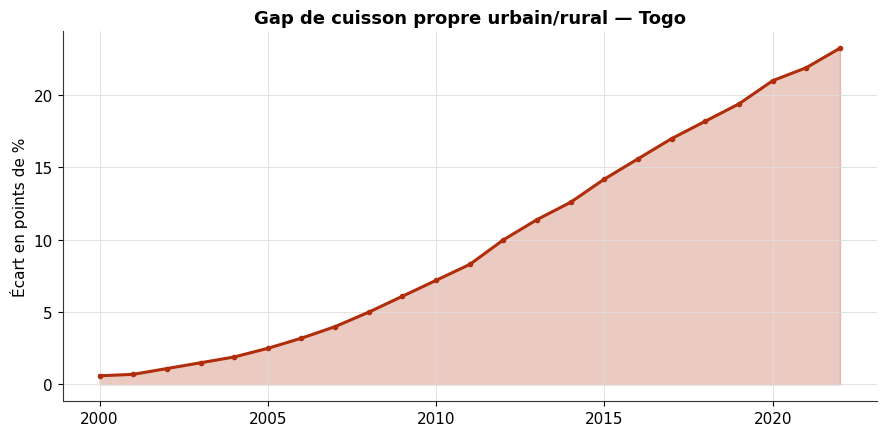

Gap de cuisson propre : 0.6 pts (2000) -> 23.2 pts (2022)
Zones prioritaires : le milieu RURAL dans son ensemble (< 1% d'accès, cf. lecture ci-dessus) — les données disponibles ne permettent pas de descendre à une maille infranationale (région/village) ; ce point est repris comme limite en Section 18.


In [13]:
# --- Gap de cuisson propre urbain/rural (Section 7 du plan d'audit) ---
annees_communes = sorted(set(clean_urban.Year) & set(clean_rural.Year))
gap_series = pd.DataFrame({
    'Year': annees_communes,
    'Urbain': clean_urban.set_index('Year').loc[annees_communes, 'Value'].values,
    'Rural': clean_rural.set_index('Year').loc[annees_communes, 'Value'].values,
})
gap_series['Gap (urbain - rural), pts'] = gap_series['Urbain'] - gap_series['Rural']

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(gap_series['Year'], 0, gap_series['Gap (urbain - rural), pts'], color=C_ALERT, alpha=0.25)
ax.plot(gap_series['Year'], gap_series['Gap (urbain - rural), pts'], color=C_ALERT, lw=2.2, marker='o', ms=3)
ax.set_title("Gap de cuisson propre urbain/rural — Togo")
ax.set_ylabel('Écart en points de %')
plt.tight_layout(); plt.savefig('figures/16_gap_cuisson_propre.png', dpi=150); plt.show()

print(f"Gap de cuisson propre : {gap_series['Gap (urbain - rural), pts'].iloc[0]:.1f} pts "
      f"({int(gap_series['Year'].iloc[0])}) -> {gap_series['Gap (urbain - rural), pts'].iloc[-1]:.1f} pts "
      f"({int(gap_series['Year'].iloc[-1])})")
print("Zones prioritaires : le milieu RURAL dans son ensemble (< 1% d'accès, cf. lecture ci-dessus) — "
      "les données disponibles ne permettent pas de descendre à une maille infranationale (région/village) ; "
      "ce point est repris comme limite en Section 18.")


**Lecture :** en zone rurale, l'accès à une cuisson propre est **quasi inexistant et stagnant (< 1 % depuis au moins une décennie)**. C'est l'angle mort le plus criant du diagnostic : sans intervention ciblée (foyers améliorés, gaz subventionné, biodigesteurs), aucune amélioration spontanée n'est à attendre en milieu rural.

In [14]:
forest_area = get_series('Forest area (sq. km)')
forest_pct  = get_series('Forest area (% of land area)')
renouvelables_s = renouvelables.dropna(subset=['value']).sort_values('date')

f_min, f_max = int(forest_area.Year.min()), int(forest_area.Year.max())

def plot_foret_biomasse(periode=(f_min, f_max)):
    y0, y1 = periode
    fa = forest_area[(forest_area.Year >= y0) & (forest_area.Year <= y1)]
    rs = renouvelables_s[(renouvelables_s.date >= y0) & (renouvelables_s.date <= y1)]

    fig, ax1 = plt.subplots(figsize=(10, 5.5))
    ax1.plot(fa.Year, fa.Value, color=C_PRIMARY, lw=2.5, label='Superficie forestière (km²)')
    ax1.set_ylabel('Superficie forestière (km²)', color=C_PRIMARY); ax1.tick_params(axis='y', labelcolor=C_PRIMARY)
    ax1.set_title("Recul du couvert forestier vs. poids de la biomasse dans le mix énergétique")

    ax2 = ax1.twinx()
    ax2.plot(rs['date'], rs['value'], color=C_ACCENT, lw=2.5, ls='--',
             label="Renouvelables + combustibles/déchets (% énergie totale)")
    ax2.set_ylabel("Part renouvelables/biomasse (%)", color=C_ACCENT); ax2.tick_params(axis='y', labelcolor=C_ACCENT)
    ax2.set_ylim(0, 100)

    l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l2, lb1 + lb2, loc='lower left', frameon=False, fontsize=9)
    plt.tight_layout(); plt.savefig('figures/05_foret_vs_biomasse.png', dpi=150); plt.show()

    if len(fa) >= 2:
        perte_km2 = fa.Value.iloc[0] - fa.Value.iloc[-1]
        duree = fa.Year.iloc[-1] - fa.Year.iloc[0]
        print(f"Superficie forestière : {fa.Value.iloc[0]:,.0f} km² ({int(fa.Year.iloc[0])}) -> {fa.Value.iloc[-1]:,.0f} km² ({int(fa.Year.iloc[-1])})")
        print(f"Perte : {perte_km2:,.0f} km² en {int(duree)} ans, soit {perte_km2/duree:,.0f} km²/an ({perte_km2/duree*100:,.0f} ha/an)")

print("🎛️ Filtre interactif — période d'observation")
interact(plot_foret_biomasse, periode=widgets.IntRangeSlider(value=[f_min, f_max], min=f_min, max=f_max, step=1,
                                                               description='Période', continuous_update=False,
                                                               layout=Layout(width='480px')));

🎛️ Filtre interactif — période d'observation


interactive(children=(IntRangeSlider(value=(1990, 2021), continuous_update=False, description='Période', layou…

**Lecture :** le Togo a perdu **≈ 1 550 km² de forêt entre 1990 et 2021 (≈ 50 km²/an, soit ~5 000 ha/an)**. Sur la même période, les « renouvelables + combustibles/déchets » représentent **durablement 75-80 % de l'énergie totale consommée** — un chiffre trompeur si on l'entend comme signal positif : dans le contexte togolais, cet indicateur est **dominé par le bois-énergie traditionnel**, non par le solaire ou l'hydroélectricité.

In [15]:
# --- KPI de déforestation : formules explicites (Section 13 du plan d'audit) ---
fa_sorted = forest_area.sort_values('Year')
foret_initiale = fa_sorted['Value'].iloc[0]; annee_i = int(fa_sorted['Year'].iloc[0])
foret_finale   = fa_sorted['Value'].iloc[-1]; annee_f = int(fa_sorted['Year'].iloc[-1])
perte_km2   = foret_initiale - foret_finale
perte_pct   = perte_km2 / foret_initiale * 100
duree_ans   = annee_f - annee_i
taux_annuel = perte_km2 / duree_ans

print("Formules : Perte = forêt_initiale - forêt_finale | Perte_% = (perte / forêt_initiale) × 100 | "
      "Taux annuel moyen = perte / nombre d'années\n")
print(f"Superficie forestière initiale : {foret_initiale:,.0f} km² ({annee_i}) [MESURE OBSERVÉE, source WDI]")
print(f"Superficie forestière finale    : {foret_finale:,.0f} km² ({annee_f}) [MESURE OBSERVÉE, source WDI]")
print(f"Perte absolue                    : {perte_km2:,.0f} km² sur {duree_ans} ans")
print(f"Perte relative                   : {perte_pct:.1f} %")
print(f"Taux annuel moyen                : {taux_annuel:,.0f} km²/an ({taux_annuel*100:,.0f} ha/an)")
print("\nCes chiffres sont des mesures observées (télédétection agrégée WDI), pas une estimation ou une projection.")


Formules : Perte = forêt_initiale - forêt_finale | Perte_% = (perte / forêt_initiale) × 100 | Taux annuel moyen = perte / nombre d'années

Superficie forestière initiale : 13,617 km² (1990) [MESURE OBSERVÉE, source WDI]
Superficie forestière finale    : 12,063 km² (2021) [MESURE OBSERVÉE, source WDI]
Perte absolue                    : 1,554 km² sur 31 ans
Perte relative                   : 11.4 %
Taux annuel moyen                : 50 km²/an (5,011 ha/an)

Ces chiffres sont des mesures observées (télédétection agrégée WDI), pas une estimation ou une projection.


---
## 7. Émissions de gaz à effet de serre — le secteur énergie face aux autres secteurs

**Question :** quel est le poids du secteur énergie dans les émissions nationales de GES, comparé à l'agriculture/foresterie, l'industrie et les déchets ?

*Source : inventaire national des émissions de GES par secteur (dernière année d'inventaire disponible : 2018).*

**⚠️ Correction d'unité appliquée (voir Section 3) :** le fichier source exprime ces valeurs en **Gg CO2e** (gigagrammes = kilotonnes). Une version antérieure de ce notebook les affichait directement comme des **Mt CO2e**, soit une valeur 1000 fois trop élevée en absolu (ex. "35 830 Mt" au lieu de 35,83 Mt). La conversion `Value_Mt = Value_Gg / 1000` a été appliquée dès le chargement (Section 3) ; tous les graphiques ci-dessous affichent donc désormais la bonne grandeur. **Les pourcentages de répartition sectorielle (87,7 % / 6,2 % / 6,1 % / 0,03 %) sont, eux, inchangés** puisqu'il s'agit de ratios internes non affectés par l'erreur d'unité.

In [16]:
tot_national = ges_sectoriel[(ges_sectoriel.secteur == 'Total') & (ges_sectoriel.type == 'Total')].Value.values[0]
secteurs_all = ges_sectoriel[(ges_sectoriel.type == 'Total') & (ges_sectoriel.secteur != 'Total')].copy()

label_map = {
    'Agriculture, Foresterie et autres Affectations des Terres (AFAT)': 'Agriculture, Foresterie\n& affectation des terres (AFAT)',
    'Energie': 'Énergie',
    'Procédés Industriels et Utilisation des Produits (PIUP)': 'Procédés industriels\n& produits (PIUP)',
    'Déchets': 'Déchets',
}
secteurs_all['label'] = secteurs_all['secteur'].map(lambda x: label_map.get(x, x))
color_map = {s: (C_PRIMARY if 'AFAT' in s or 'Agri' in s else (C_BLUE if s == 'Energie' else
             (C_GREY if s == 'Déchets' else C_ACCENT))) for s in secteurs_all['secteur']}

def plot_secteurs(secteurs_choisis=tuple(secteurs_all['secteur']), base_pct='Total national'):
    sub = secteurs_all[secteurs_all['secteur'].isin(secteurs_choisis)].sort_values('Value', ascending=True)
    denom = tot_national if base_pct == 'Total national' else sub['Value'].sum()
    sub = sub.copy(); sub['part_pct'] = sub.Value / denom * 100

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(sub['label'], sub['Value'], color=[color_map[s] for s in sub['secteur']])
    for bar, v, p in zip(bars, sub['Value'], sub['part_pct']):
        ax.text(bar.get_width() + tot_national*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:,.2f} Mt CO2e  ({p:.1f}%)', va='center', fontsize=9.5, fontweight='bold')
    ax.set_xlabel('Émissions (Mt CO2e)')
    base_lbl = 'du total national' if base_pct == 'Total national' else 'des secteurs sélectionnés'
    ax.set_title(f"Émissions de GES par secteur — Togo, {int(ges_sectoriel['Date'].iloc[0])}  (% {base_lbl})")
    ax.set_xlim(0, sub['Value'].max()*1.35 if len(sub) else 1)
    plt.tight_layout(); plt.savefig('figures/06_ges_par_secteur.png', dpi=150); plt.show()
    print(sub[['secteur', 'Value', 'part_pct']].sort_values('Value', ascending=False).to_string(index=False))

print("🎛️ Filtre interactif — secteurs inclus et base de calcul du %")
interact(plot_secteurs,
         secteurs_choisis=widgets.SelectMultiple(options=list(secteurs_all['secteur']), value=tuple(secteurs_all['secteur']),
                                                   description='Secteurs', layout=Layout(width='420px')),
         base_pct=widgets.ToggleButtons(options=['Total national', 'Secteurs sélectionnés'], description='Base %'));

🎛️ Filtre interactif — secteurs inclus et base de calcul du %


interactive(children=(SelectMultiple(description='Secteurs', index=(0, 1, 2, 3), layout=Layout(width='420px'),…

**Lecture :** le secteur **AFAT (Agriculture, Foresterie et Affectation des Terres) domine très largement le bilan carbone national avec 87,7 % des émissions** — cohérent avec le rythme de déforestation quantifié en Section 2. **Le secteur Énergie ne pèse que 6,2 %**, à un niveau comparable aux Procédés Industriels. **Conséquence stratégique : dans les données analysées, la gestion des terres et des forêts pèse bien plus lourd que la production électrique dans le bilan carbone national — le secteur AFAT constitue le principal contributeur au bilan d'émissions de GES du Togo.**

In [17]:
energie_gaz = ges_sectoriel[(ges_sectoriel.secteur == 'Energie') & (ges_sectoriel.type != 'Total')]

def plot_gaz_energie(unite='% du secteur Énergie'):
    fig, ax = plt.subplots(figsize=(6.5, 5))
    colors_gas = [C_BLUE, C_ACCENT, C_ALERT]
    if unite == '% du secteur Énergie':
        ax.pie(energie_gaz['Value'], labels=energie_gaz['type'], autopct='%1.0f%%', colors=colors_gas,
               startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    else:
        ax.bar(energie_gaz['type'], energie_gaz['Value'], color=colors_gas)
        ax.set_ylabel('Mt CO2e'); plt.xticks(rotation=15, ha='right')
    ax.set_title('Composition des émissions du secteur Énergie, par gaz')
    plt.tight_layout(); plt.savefig('figures/07_energie_par_gaz.png', dpi=150); plt.show()
    print(energie_gaz[['type', 'Value']].to_string(index=False))

print("🎛️ Filtre interactif — unité d'affichage")
interact(plot_gaz_energie, unite=widgets.ToggleButtons(options=['% du secteur Énergie', 'Mt CO2e (absolu)'], description='Unité'));

🎛️ Filtre interactif — unité d'affichage


interactive(children=(ToggleButtons(description='Unité', options=('% du secteur Énergie', 'Mt CO2e (absolu)'),…

In [18]:
co2_e = co2_energie.dropna(subset=['value']).sort_values('date')
c_min, c_max = int(co2_e.date.min()), int(co2_e.date.max())

def plot_co2_trend(periode=(c_min, c_max)):
    y0, y1 = periode
    sub = co2_e[(co2_e.date >= y0) & (co2_e.date <= y1)]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(sub['date'], sub['value'], color=C_BLUE, lw=2)
    ax.fill_between(sub['date'], sub['value'], color=C_BLUE, alpha=0.12)
    ax.set_title("Émissions de CO2 du secteur de l'énergie — évolution")
    ax.set_ylabel('Mt CO2e')
    plt.tight_layout(); plt.savefig('figures/08_co2_energie_trend.png', dpi=150); plt.show()
    if len(sub) >= 2:
        print(f"CO2 secteur énergie : {sub['value'].iloc[0]:.3f} Mt ({sub['date'].iloc[0]}) -> {sub['value'].iloc[-1]:.3f} Mt ({sub['date'].iloc[-1]})")
        if sub['value'].iloc[0] > 0:
            print(f"Facteur multiplicatif : x{sub['value'].iloc[-1]/sub['value'].iloc[0]:.1f}")

print("🎛️ Filtre interactif — période d'observation")
interact(plot_co2_trend, periode=widgets.IntRangeSlider(value=[c_min, c_max], min=c_min, max=c_max, step=1,
                                                          description='Période', continuous_update=False,
                                                          layout=Layout(width='480px')));

🎛️ Filtre interactif — période d'observation


interactive(children=(IntRangeSlider(value=(1970, 2022), continuous_update=False, description='Période', layou…

**Lecture :** en tendance longue, les émissions de CO2 du secteur énergie **augmentent structurellement**, portées par la croissance démographique et l'urbanisation. Le secteur reste minoritaire dans le bilan national aujourd'hui, mais **sa trajectoire de croissance en fait un enjeu montant** — d'où l'intérêt du solaire décentralisé (Section 5) qui limite la dépendance future aux combustibles fossiles.

---
## 8. Analyse climatique — dix stations, du Sud au Nord

**Question :** comment les températures évoluent-elles du Sud (Lomé, littoral) au Nord (Dapaong, zone sahélienne), et quel est le lien avec les besoins en énergie ?

*Source : relevés mensuels de températures maximales/minimales, 10 stations, janvier 2013 - septembre 2019.*

In [19]:
villes_ordre = ['Lomé', 'Tabligbo', 'Kouma konda', 'Atakpamé', 'Sotouboua', 'Sokodé', 'Kara', 'Niamtougou', 'Mango', 'Dapaong']
villes_coords = {
    'Lomé': (1.22, 6.13), 'Tabligbo': (1.50, 6.58), 'Kouma konda': (0.74, 7.13),
    'Atakpamé': (1.13, 7.53), 'Sotouboua': (0.98, 8.58), 'Sokodé': (1.13, 8.98),
    'Kara': (1.19, 9.55), 'Niamtougou': (1.10, 9.77), 'Mango': (0.47, 10.36), 'Dapaong': (0.20, 10.86)
}

moyennes = temperatures.groupby(['villes', 'libellés'])['Value'].mean().unstack().reindex(villes_ordre)
moyennes.columns.name = None

t_min, t_max = int(temperatures.Year.min()), int(temperatures.Year.max())

def plot_temperatures(villes=tuple(villes_ordre), periode=(t_min, t_max), metriques=('Max', 'Min')):
    y0, y1 = periode
    sub = temperatures[(temperatures.Year >= y0) & (temperatures.Year <= y1) & (temperatures.villes.isin(villes))]
    m = sub.groupby(['villes', 'libellés'])['Value'].mean().unstack().reindex([v for v in villes_ordre if v in villes])
    x = np.arange(len(m))

    fig, ax = plt.subplots(figsize=(11, 5.5))
    if 'Max' in metriques and 'Températures maximales' in m.columns:
        ax.plot(x, m['Températures maximales'], color=C_ALERT, lw=2.5, marker='o', label='T° maximale moyenne')
    if 'Min' in metriques and 'Températures minimales' in m.columns:
        ax.plot(x, m['Températures minimales'], color=C_BLUE, lw=2.5, marker='o', label='T° minimale moyenne')
    if {'Max', 'Min'}.issubset(metriques) and {'Températures maximales', 'Températures minimales'}.issubset(m.columns):
        ax.fill_between(x, m['Températures minimales'], m['Températures maximales'], color=C_ACCENT, alpha=0.12)
    ax.set_xticks(x); ax.set_xticklabels(m.index, rotation=30, ha='right')
    ax.set_ylabel('Température (°C)')
    ax.set_title(f'Températures moyennes ({y0}-{y1}) — du Sud (Lomé) au Nord (Dapaong)')
    ax.legend(frameon=False)
    plt.tight_layout(); plt.savefig('figures/09_temperatures_sud_nord.png', dpi=150); plt.show()
    print(m.round(1))

print("🎛️ Filtre interactif — villes, période et métrique")
interact(plot_temperatures,
         villes=widgets.SelectMultiple(options=villes_ordre, value=tuple(villes_ordre), description='Villes',
                                        layout=Layout(width='260px', height='170px')),
         periode=widgets.IntRangeSlider(value=[t_min, t_max], min=t_min, max=t_max, step=1, description='Période',
                                         continuous_update=False, layout=Layout(width='420px')),
         metriques=widgets.SelectMultiple(options=['Max', 'Min'], value=('Max', 'Min'), description='Métrique',
                                           layout=Layout(width='160px', height='60px')));

🎛️ Filtre interactif — villes, période et métrique


interactive(children=(SelectMultiple(description='Villes', index=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9), layout=Layout…

**Lecture :** le gradient Sud-Nord n'est **pas parfaitement linéaire** mais la tendance de fond est nette : les stations septentrionales de la zone des savanes (**Mango, Dapaong, Kara**) affichent les températures maximales moyennes les plus élevées, contre **Kouma Konda (zone de relief/plateau boisé) et Lomé (effet tampon de l'océan)** au Sud. Décochez des villes dans le filtre pour comparer un sous-ensemble régional.

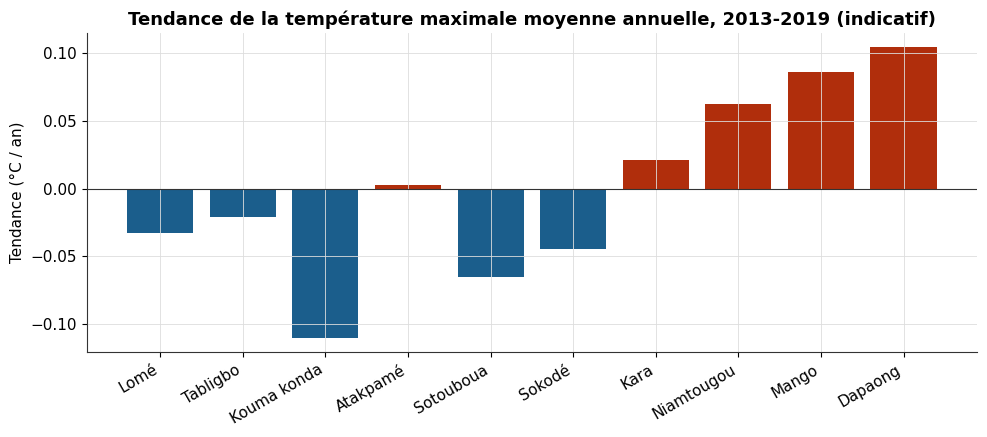

Lomé          -0.033
Tabligbo      -0.021
Kouma konda   -0.110
Atakpamé       0.003
Sotouboua     -0.065
Sokodé        -0.045
Kara           0.021
Niamtougou     0.062
Mango          0.086
Dapaong        0.104
dtype: float64


In [20]:
tendances = {}
for ville in villes_ordre:
    sub = temperatures[(temperatures.villes == ville) & (temperatures['libellés'] == 'Températures maximales')].groupby('Year')['Value'].mean()
    if len(sub) >= 2:
        pente, _ = np.polyfit(sub.index, sub.values, 1)
        tendances[ville] = pente
tendances_s = pd.Series(tendances).reindex(villes_ordre)

fig, ax = plt.subplots(figsize=(10, 4.5))
colors_trend = [C_ALERT if v > 0 else C_BLUE for v in tendances_s.values]
ax.bar(tendances_s.index, tendances_s.values, color=colors_trend)
ax.axhline(0, color='#333333', lw=0.8)
ax.set_ylabel('Tendance (°C / an)')
ax.set_title('Tendance de la température maximale moyenne annuelle, 2013-2019 (indicatif)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.savefig('figures/10_tendance_rechauffement.png', dpi=150); plt.show()
print(tendances_s.round(3))

**Lecture (avec prudence statistique) :** sur cette fenêtre courte (7 ans), les villes du **Nord (Dapaong, Mango, Niamtougou)** montrent une tendance au réchauffement nettement plus marquée que le Sud. **Ces pentes ne sont pas des tendances climatiques robustes** — 7 ans est trop court pour distinguer signal climatique et variabilité interannuelle — mais elles sont cohérentes avec la vulnérabilité déjà documentée du Nord (Section 5) et renforcent l'urgence d'y déployer des solutions énergétiques résilientes (froid alimentaire, ventilation, pompage solaire).

In [21]:
# --- Statistiques de tendance formelles : R², p-value, IC95%, Mann-Kendall, pente de Sen (Section 14 du plan d'audit) ---
lignes_stats = []
for ville in villes_ordre:
    sub = (temperatures[(temperatures.villes == ville) & (temperatures['libellés'] == 'Températures maximales')]
           .groupby('Year')['Value'].mean())
    if len(sub) < 4:
        continue
    x = sub.index.values.astype(float); y = sub.values
    slope, intercept, r, p, se = scistats.linregress(x, y)
    n = len(x); tval = scistats.t.ppf(0.975, max(n - 2, 1))
    ic95 = tval * se
    mk_res = pmk.original_test(y)
    lignes_stats.append({
        'Ville': ville, "Années": n, 'Pente OLS (°C/an)': round(slope, 4), 'IC95% (±)': round(ic95, 4),
        'R²': round(r**2, 3), 'p-value (OLS)': round(p, 3),
        'Mann-Kendall': mk_res.trend, 'p-value (MK)': round(mk_res.p, 3), "Pente de Sen (°C/an)": round(mk_res.slope, 4),
    })
stats_climat_df = pd.DataFrame(lignes_stats)
display(stats_climat_df.style.hide(axis='index'))

n_sig = (stats_climat_df['p-value (MK)'] < 0.05).sum()
print(f"\nSeules {n_sig}/{len(stats_climat_df)} station(s) présentent une tendance Mann-Kendall statistiquement "
      f"significative au seuil de 5% : {', '.join(stats_climat_df.loc[stats_climat_df['p-value (MK)'] < 0.05, 'Ville'])}.")
print("Pour toutes les autres stations, la pente affichée dans le graphique précédent est un signal indicatif "
      "cohérent avec le gradient Sud-Nord déjà connu, mais NE constitue PAS une preuve statistique de réchauffement "
      "local sur cette fenêtre de 7 ans — résultat à interpréter avec prudence, conformément au test de Mann-Kendall "
      "(non paramétrique, robuste aux valeurs aberrantes et adapté aux séries courtes et non normalement distribuées).")


Ville,Années,Pente OLS (°C/an),IC95% (±),R²,p-value (OLS),Mann-Kendall,p-value (MK),Pente de Sen (°C/an)
Lomé,7,-0.032700,0.101400,0.121000,0.445000,no trend,0.759000,-0.020800
Tabligbo,7,-0.020800,0.196400,0.015000,0.796000,no trend,0.649000,-0.041700
Kouma konda,7,-0.110100,0.151400,0.411000,0.121000,no trend,0.133000,-0.083300
Atakpamé,7,0.003000,0.127200,0.001000,0.954000,no trend,0.759000,0.016700
Sotouboua,7,-0.065500,0.286700,0.064000,0.583000,no trend,0.288000,-0.066700
Sokodé,7,-0.044600,0.055500,0.461000,0.093000,no trend,0.112000,-0.033300
Kara,7,0.020800,0.104200,0.050000,0.629000,no trend,1.000000,0.000000
Niamtougou,7,0.062500,0.101900,0.332000,0.176000,no trend,0.219000,0.066700
Mango,7,0.086300,0.071700,0.657000,0.027000,increasing,0.026000,0.083300
Dapaong,7,0.104200,0.116900,0.512000,0.071000,no trend,0.172000,0.125000



Seules 1/10 station(s) présentent une tendance Mann-Kendall statistiquement significative au seuil de 5% : Mango.
Pour toutes les autres stations, la pente affichée dans le graphique précédent est un signal indicatif cohérent avec le gradient Sud-Nord déjà connu, mais NE constitue PAS une preuve statistique de réchauffement local sur cette fenêtre de 7 ans — résultat à interpréter avec prudence, conformément au test de Mann-Kendall (non paramétrique, robuste aux valeurs aberrantes et adapté aux séries courtes et non normalement distribuées).


## 9. Forêts et aires protégées

**Question :** où se situent les forêts classées du cadastre fourni, et que peut-on dire de la couverture réelle de protection forestière du Togo à partir de ce jeu de données ?

**⚠️ Correction critique (Section 8 du plan d'audit) :** le jeu de données géospatial fourni contient **53 polygones de forêts classées**. Ce chiffre est le **nombre d'entités présentes dans le fichier utilisé pour cette analyse** — ce n'est **pas** l'inventaire exhaustif des aires protégées du Togo. Le registre international de référence (Protected Planet / WDPA, consulté en 2026) recense **83 désignations nationales** pour le Togo (parcs nationaux, réserves de faune, forêts classées, etc.), soit un périmètre plus large que celui couvert ici. Toutes les analyses ci-dessous portent donc explicitement sur le sous-ensemble « forêts classées » du cadastre national, pas sur la totalité du dispositif d'aires protégées.

In [22]:
# --- 5.1 Préparation géospatiale ---
forets_m = forets.to_crs(32631)  # UTM 31N, adapté au Togo pour un calcul d'aire/distance correct
forets['area_km2'] = forets_m.geometry.area / 1e6
forets['centroid'] = forets_m.geometry.centroid.to_crs(4326)
forets['lon'] = forets['centroid'].x
forets['lat'] = forets['centroid'].y
forets = forets.reset_index(drop=True)

print(f"Nombre de forêts classées / zones protégées : {len(forets)}")
print(f"Superficie totale couverte : {forets['area_km2'].sum():,.0f} km²")
print(f"Superficie médiane : {forets['area_km2'].median():.1f} km²  |  min : {forets['area_km2'].min():.3f} km²  |  max : {forets['area_km2'].max():.1f} km²")
print()
print(forets['region_nom_bdd'].value_counts().rename('Nombre de forêts'))

Nombre de forêts classées / zones protégées : 53
Superficie totale couverte : 915 km²
Superficie médiane : 3.9 km²  |  min : 0.001 km²  |  max : 183.1 km²

region_nom_bdd
Plateaux    20
Kara        12
Maritime    10
Centrale     7
Savanes      4
Name: Nombre de forêts, dtype: int64


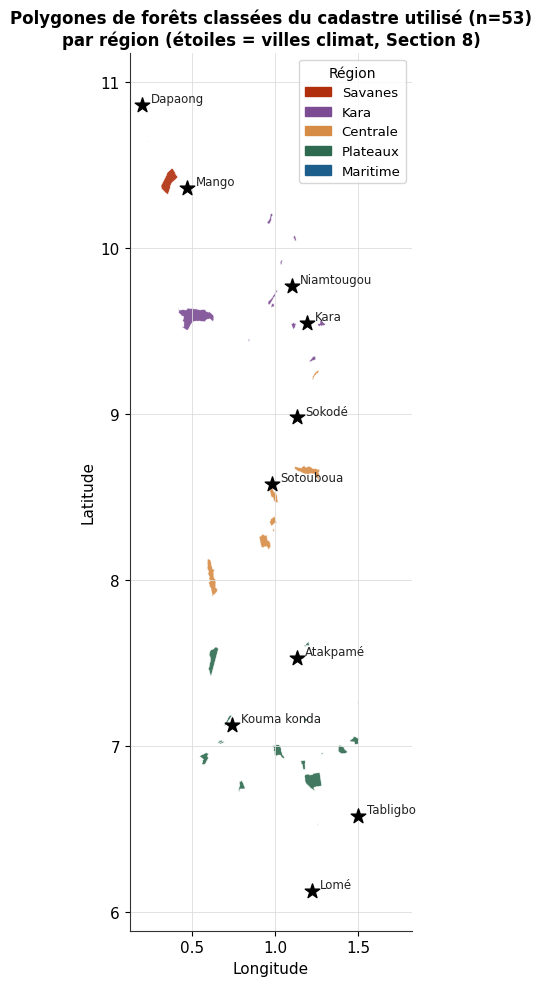

In [23]:
# Carte statique de référence (répartition par région + villes climat, comme repère de contexte)
fig, ax = plt.subplots(figsize=(8.5, 10))
for region, sub in forets.groupby('region_nom_bdd'):
    sub.plot(ax=ax, color=REGION_COLORS.get(region, C_GREY), edgecolor='white', linewidth=0.4, alpha=0.9)
for ville, (lon, lat) in villes_coords.items():
    ax.scatter(lon, lat, marker='*', s=120, color='black', zorder=5)
    ax.annotate(ville, (lon, lat), textcoords="offset points", xytext=(6, 2), fontsize=8.5, color='#222222')
ax.set_title("Polygones de forêts classées du cadastre utilisé (n=53)\npar région (étoiles = villes climat, Section 8)", fontsize=12)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
legend_handles = [mpatches.Patch(color=REGION_COLORS[r], label=r) for r in ['Savanes', 'Kara', 'Centrale', 'Plateaux', 'Maritime']]
ax.legend(handles=legend_handles, title='Région', loc='upper right', frameon=True, fontsize=9.5, title_fontsize=10)
ax.set_aspect('equal')
plt.tight_layout(); plt.savefig('figures/11_carte_forets_classees.png', dpi=150, bbox_inches='tight'); plt.show()

In [24]:
# --- Comparaison au registre international + Indice de couverture protégée régionale (Section 9 du plan d'audit) ---

# Superficies régionales : valeurs publiées (cartographie administrative togolaise), approximatives — non fournies
# par le cadastre du Data Challenge. Utilisées uniquement comme dénominateur pour normaliser le compte de forêts classées.
superficie_region_km2 = {
    'Maritime': 6100, 'Plateaux': 16975, 'Centrale': 13182, 'Kara': 11630, 'Savanes': 8602,
}
# Source : compilations cartographiques publiques des régions administratives du Togo (ordre de grandeur cohérent
# avec la superficie totale du pays, ≈56 600 km²) — à vérifier auprès de l'INSEED/IGN-Togo pour un usage officiel.

cov = forets.groupby('region_nom_bdd').agg(nb_forets=('area_km2', 'size'), superficie_protegee_km2=('area_km2', 'sum'))
cov['superficie_region_km2'] = cov.index.map(superficie_region_km2)
cov['couverture_pct'] = cov['superficie_protegee_km2'] / cov['superficie_region_km2'] * 100
cov['part_du_nb_total_pct'] = cov['nb_forets'] / cov['nb_forets'].sum() * 100
cov = cov.sort_values('couverture_pct', ascending=False)

display(cov.round(3).style.hide(axis='index', names=False))

print(f"\nComparaison au registre international : {len(forets)} polygones de forêts classées dans ce jeu de données, "
      f"contre 83 désignations nationales pour le Togo au registre Protected Planet/WDPA (accès janvier 2026) — "
      f"l'écart s'explique par des catégories non couvertes ici (parcs nationaux, réserves de faune).")
print("\nL'indice de couverture régionale change la lecture : la Région Maritime concentre 10 forêts classées "
      f"(={cov.loc['Maritime','part_du_nb_total_pct']:.0f}% du nombre total) mais couvre seulement "
      f"{cov.loc['Maritime','couverture_pct']:.3f}% de sa superficie régionale — la plus faible couverture réelle "
      "des 5 régions, malgré un nombre d'entités élevé (nombreux petits polygones, ex. bosquets sacrés / mangroves). "
      "À l'inverse, la région Savanes, souvent citée comme 'sous-dotée' au vu de son faible nombre de forêts (4), "
      f"affiche une couverture de {cov.loc['Savanes','couverture_pct']:.2f}% de son territoire, du même ordre de "
      "grandeur que Plateaux et Centrale. Conclusion : le nombre brut de polygones par région est un indicateur "
      "trompeur du niveau de protection ; la couverture rapportée à la superficie régionale nuance fortement le "
      "diagnostic 'Nord sous-protégé' tiré d'une lecture au seul décompte.")


nb_forets,superficie_protegee_km2,superficie_region_km2,couverture_pct,part_du_nb_total_pct
12,246.733000,11630,2.122000,22.642000
7,255.493000,13182,1.938000,13.208000
20,319.839000,16975,1.884000,37.736000
4,92.335000,8602,1.073000,7.547000
10,0.605000,6100,0.010000,18.868000



Comparaison au registre international : 53 polygones de forêts classées dans ce jeu de données, contre 83 désignations nationales pour le Togo au registre Protected Planet/WDPA (accès janvier 2026) — l'écart s'explique par des catégories non couvertes ici (parcs nationaux, réserves de faune).

L'indice de couverture régionale change la lecture : la Région Maritime concentre 10 forêts classées (=19% du nombre total) mais couvre seulement 0.010% de sa superficie régionale — la plus faible couverture réelle des 5 régions, malgré un nombre d'entités élevé (nombreux petits polygones, ex. bosquets sacrés / mangroves). À l'inverse, la région Savanes, souvent citée comme 'sous-dotée' au vu de son faible nombre de forêts (4), affiche une couverture de 1.07% de son territoire, du même ordre de grandeur que Plateaux et Centrale. Conclusion : le nombre brut de polygones par région est un indicateur trompeur du niveau de protection ; la couverture rapportée à la superficie régionale nuance forteme

**Lecture (révisée) :** en nombre brut de polygones, les forêts classées sont concentrées en Plateaux (20, 38%) et Kara (12, 23%), avec seulement 4 en Savanes (8%). **Mais rapporté à la taille de chaque région (indice de couverture ci-dessus), ce déséquilibre apparent s'atténue fortement** : Savanes (≈1,1% du territoire régional protégé) est comparable à Plateaux et Centrale (≈1,9-1,9%), tandis que Maritime — pourtant en 2ᵉ position en nombre de forêts (10) — affiche la couverture la plus faible de toutes les régions en proportion de son territoire (≈0,01%). L'écart Nord/Sud sur ce jeu de données spécifique doit donc être interprété avec prudence : il ne permet pas, à lui seul, de conclure à un déficit régional de protection sans vérification complémentaire (ex. auprès de la Direction Générale de l'Environnement togolaise ou de Protected Planet pour le périmètre complet des 83 désignations nationales).

## 10. Analyse par graphes et centralité — réseau de proximité géographique des zones forestières

**Précision terminologique (Section 10 du plan d'audit) :** le graphe construit ci-dessous mesure une **centralité dans un réseau de proximité géographique** entre les 53 forêts classées (distance euclidienne en projection métrique). Il ne s'agit **pas** d'un réseau écologique mesuré (pas de données de flux génétique, de mouvement de faune ou de connectivité d'habitat réelle) : la proximité spatiale est un **proxy**, pas une preuve de connectivité écologique effective. Ce notebook parle donc systématiquement de « centralité structurelle » ou « centralité de proximité géographique », jamais de « centralité écologique ».

### 5.2 Réseau de proximité et centralité structurelle

**Méthode :** on relie chaque forêt à ses **k plus proches voisines** (k=4, distance euclidienne en projection métrique UTM) pour former un graphe de proximité — un proxy simple de connectivité écologique potentielle entre massifs forestiers. On y calcule trois indices de **centralité** (théorie des graphes, `networkx`) :

- **Centralité de degré** : nombre de connexions directes (forêts très proches les unes des autres) ;
- **Centralité d'intermédiarité (betweenness)** : à quel point une forêt se situe sur les chemins les plus courts entre d'autres forêts — un score élevé signale un **nœud de corridor**, stratégique pour la connectivité globale du réseau d'aires protégées ;
- **Centralité de proximité (closeness)** : à quel point une forêt est en moyenne "proche" de toutes les autres.

Une forêt à forte centralité n'est pas nécessairement menacée (cf. indice de vulnérabilité, 5.3) : elle est **structurellement importante pour le réseau** — sa perte fragiliserait la connectivité de l'ensemble, et elle constitue un point d'ancrage naturel pour des programmes énergétiques/forestiers desservant plusieurs zones à la fois.

In [25]:
K_VOISINS = 4
coords_m = np.column_stack([forets_m.geometry.centroid.x, forets_m.geometry.centroid.y])
tree = cKDTree(coords_m)
dist, idx = tree.query(coords_m, k=K_VOISINS + 1)  # colonne 0 = soi-même

G = nx.Graph()
for i, row in forets.iterrows():
    G.add_node(i, nom=row['etab_nom'], region=row['region_nom_bdd'])
for i in range(len(forets)):
    for pos in range(1, K_VOISINS + 1):
        j = int(idx[i, pos]); d_km = dist[i, pos] / 1000
        if d_km > 0:
            G.add_edge(i, j, distance_km=d_km)

deg_c   = nx.degree_centrality(G)
btw_c   = nx.betweenness_centrality(G, weight='distance_km', normalized=True)
close_c = nx.closeness_centrality(G, distance='distance_km')

forets['centralite_degre']          = forets.index.map(deg_c)
forets['centralite_intermediarite'] = forets.index.map(btw_c)
forets['centralite_proximite']      = forets.index.map(close_c)
forets['centralite_score'] = (forets['centralite_intermediarite'].rank(pct=True) * 100).round(1)

print(f"Graphe de proximité : {G.number_of_nodes()} forêts, {G.number_of_edges()} liaisons (k={K_VOISINS} plus proches voisines)")
print(f"Distance moyenne entre forêts voisines : {np.mean([d['distance_km'] for _,_,d in G.edges(data=True)]):.1f} km")
print()
print("Top 8 forêts par centralité d'intermédiarité (nœuds de corridor) :")
print(forets.nlargest(8, 'centralite_intermediarite')[['etab_nom','region_nom_bdd','centralite_intermediarite','centralite_score']].to_string(index=False))

# Eigenvector centrality (indice supplémentaire, Section 10 du plan d'audit)
try:
    eig_c = nx.eigenvector_centrality(G, weight='distance_km', max_iter=1000)
    forets['centralite_eigenvector'] = forets.index.map(eig_c)
    print("\nCentralité de vecteur propre (eigenvector) calculée avec succès — corrélation avec l'intermédiarité :",
          round(forets['centralite_eigenvector'].corr(forets['centralite_intermediarite']), 2))
except nx.PowerIterationFailedConvergence:
    print("\nCentralité de vecteur propre : non convergente sur ce graphe (réseau trop fragmenté / peu dense) — non retenue.")


Graphe de proximité : 53 forêts, 132 liaisons (k=4 plus proches voisines)
Distance moyenne entre forêts voisines : 28.9 km

Top 8 forêts par centralité d'intermédiarité (nœuds de corridor) :
                   etab_nom region_nom_bdd  centralite_intermediarite  centralite_score
                 Haho-baloe       Plateaux                   0.117647             100.0
     Forêt classée d'assime       Plateaux                   0.095023              98.1
Forêt classée des Deux Bena       Plateaux                   0.085973              96.2
    Forêt classée Assoukoko       Centrale                   0.075415              93.4
           Wahala-agbatitoe       Plateaux                   0.075415              93.4
    Forêt classée Kanaville       Plateaux                   0.047511              90.6
   Forêt classée de Natiwah           Kara                   0.036199              88.7
        Forêt classée Manda           Kara                   0.035445              86.8

Centralité de ve

In [26]:
def plot_reseau(colorer_par='Région', mettre_en_evidence_top=5):
    pos = {i: (forets.loc[i, 'lon'], forets.loc[i, 'lat']) for i in G.nodes()}
    fig, ax = plt.subplots(figsize=(9, 10.5))
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#c9c9c9', width=0.9, alpha=0.7)

    if colorer_par == 'Région':
        node_colors = [REGION_COLORS.get(forets.loc[i, 'region_nom_bdd'], C_GREY) for i in G.nodes()]
    else:
        vals = np.array([forets.loc[i, 'centralite_intermediarite'] for i in G.nodes()])
        vmax = vals.max() if vals.max() > 0 else 1
        node_colors = plt.cm.YlOrRd(0.15 + 0.85 * vals / vmax)

    node_sizes = [120 + 3800 * forets.loc[i, 'centralite_intermediarite'] for i in G.nodes()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                            edgecolors='white', linewidths=0.8)

    top_idx = forets['centralite_intermediarite'].sort_values(ascending=False).head(mettre_en_evidence_top).index
    for i in top_idx:
        ax.annotate(forets.loc[i, 'etab_nom'][:28], pos[i], fontsize=8, fontweight='bold', color='#222222',
                    xytext=(5, 4), textcoords='offset points')

    ax.set_title(f"Réseau de proximité des 53 forêts classées (k={K_VOISINS} plus proches voisines)\n"
                 f"Taille des nœuds = centralité d'intermédiarité (rôle de corridor)", fontsize=11.5)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_aspect('equal')
    if colorer_par == 'Région':
        legend_handles = [mpatches.Patch(color=REGION_COLORS[r], label=r) for r in ['Savanes', 'Kara', 'Centrale', 'Plateaux', 'Maritime']]
        ax.legend(handles=legend_handles, title='Région', loc='upper right', fontsize=9, title_fontsize=9.5)
    plt.tight_layout(); plt.savefig('figures/12_reseau_centralite.png', dpi=150, bbox_inches='tight'); plt.show()

print("🎛️ Filtre interactif — coloration du réseau et nombre de nœuds étiquetés")
interact(plot_reseau,
         colorer_par=widgets.ToggleButtons(options=['Région', "Centralité d'intermédiarité"], description='Couleur'),
         mettre_en_evidence_top=widgets.IntSlider(value=5, min=0, max=15, step=1, description='Étiquettes (top N)'));

🎛️ Filtre interactif — coloration du réseau et nombre de nœuds étiquetés


interactive(children=(ToggleButtons(description='Couleur', options=('Région', "Centralité d'intermédiarité"), …

**Lecture :** le réseau de proximité fait apparaître des **grappes régionales cohérentes** (Plateaux, Kara) reliées par quelques forêts "pont" à forte intermédiarité — ce sont les nœuds dont la taille est la plus grande sur le graphe. Ces forêts jouent un rôle disproportionné dans la connectivité globale : leur dégradation isolerait plusieurs sous-réseaux régionaux les uns des autres. Basculez la coloration sur "Centralité d'intermédiarité" pour les repérer visuellement en un coup d'œil.

In [27]:
# --- Test de robustesse du graphe : K = 3, 4, 5, 6 (Section 11 du plan d'audit) ---
resultats_k = {}
for k in [3, 4, 5, 6]:
    _, deg_k, btw_k, close_k = calculate_centrality(forets, coords_m, k)
    resultats_k[k] = pd.Series(btw_k)

robustesse_df = pd.DataFrame(resultats_k)
robustesse_df.columns = [f'K={k}' for k in [3, 4, 5, 6]]
robustesse_df['nom'] = forets['etab_nom'].values
robustesse_df['region'] = forets['region_nom_bdd'].values

# Rang percentile par colonne K (plutôt que la valeur brute, pour rendre les K comparables entre eux)
for k in [3, 4, 5, 6]:
    robustesse_df[f'rang_K={k}'] = robustesse_df[f'K={k}'].rank(pct=True) * 100

cols_rang = [f'rang_K={k}' for k in [3, 4, 5, 6]]
robustesse_df['score_robuste'] = robustesse_df[cols_rang].mean(axis=1)
robustesse_df['ecart_type_rang'] = robustesse_df[cols_rang].std(axis=1)

top_robuste = robustesse_df.sort_values('score_robuste', ascending=False).head(10)
print("Zones dont la centralité d'intermédiarité reste élevée quel que soit K (rang percentile moyen sur K=3..6) :\n")
display(top_robuste[['nom', 'region'] + cols_rang + ['score_robuste', 'ecart_type_rang']].round(1)
        .style.hide(axis='index'))

print("\nUn faible écart-type de rang (colonne 'ecart_type_rang') signale une zone dont l'importance structurelle "
      "ne dépend pas du choix arbitraire de K -> ce sont les candidates les plus solides pour une priorisation "
      "opérationnelle (reprises dans l'Indice de priorité territoriale, Section 16).")


Zones dont la centralité d'intermédiarité reste élevée quel que soit K (rang percentile moyen sur K=3..6) :



nom,region,rang_K=3,rang_K=4,rang_K=5,rang_K=6,score_robuste,ecart_type_rang
Forêt classée des Deux Bena,Plateaux,99.100000,96.200000,100.000000,79.200000,93.600000,9.700000
Forêt classée Assoukoko,Centrale,99.100000,93.400000,98.100000,81.100000,92.900000,8.200000
Forêt classée de Kindja,Kara,92.500000,79.200000,83.000000,86.800000,85.400000,5.600000
Forêt classée Manda,Kara,95.300000,86.800000,81.100000,56.600000,80.000000,16.600000
Azakpeve,Plateaux,73.600000,83.000000,64.200000,88.700000,77.400000,10.800000
Tchorogo,Centrale,32.100000,84.900000,92.500000,92.500000,75.500000,29.100000
Haho-baloe,Plateaux,32.100000,100.000000,90.600000,77.400000,75.000000,30.100000
Djemegni,Plateaux,83.000000,81.100000,68.900000,64.200000,74.300000,9.200000
Forêt classée de Kabou,Kara,83.000000,73.600000,71.700000,67.900000,74.100000,6.400000
Forêt classée de Sirika,Kara,78.300000,65.100000,73.600000,75.500000,73.100000,5.700000



Un faible écart-type de rang (colonne 'ecart_type_rang') signale une zone dont l'importance structurelle ne dépend pas du choix arbitraire de K -> ce sont les candidates les plus solides pour une priorisation opérationnelle (reprises dans l'Indice de priorité territoriale, Section 16).


## 11. Analyse géospatiale — priorisation opérationnelle et carte interactive

**Note sur la projection cartographique (Section 12 du plan d'audit) :** tous les calculs de surface et de distance de ce notebook (superficies des forêts en km², distances de plus proches voisins du graphe de centralité) sont effectués en **projection UTM 31N (EPSG:32631)**, une projection métrique adaptée à l'emprise longitudinale du Togo, appliquée dès la Section 9 (`forets_m = forets.to_crs(32631)`). Aucun calcul de distance ou de surface n'est fait directement en latitude/longitude (EPSG:4326), ce qui aurait introduit une distorsion croissante avec la latitude. Les cartes ci-dessous (matplotlib et Leaflet/folium) réutilisent WGS84 (EPSG:4326) uniquement pour l'**affichage**, jamais pour un calcul.

### 11.1 Indice de vulnérabilité et matrice de priorisation

**Indice de vulnérabilité (heuristique, transparent, pondérable) :**
- **Risque de disparition** : plus une forêt est petite, plus elle est vulnérable (effet de lisière, exploitation illégale plus facile à dissimuler) ;
- **Lacune de suivi** : date de création non documentée (`Nsp`/`Nps`/`Jadis`) = zone hors radar administratif, prioritaire pour un état des lieux.

Les curseurs ci-dessous permettent de **repondérer l'indice en direct** et d'observer comment le classement des forêts prioritaires évolue.

*NB : en l'absence de données de télédétection (NDVI, alertes de déforestation), cet indice est un proxy de priorisation à affiner, pas une mesure directe de déforestation.*

In [28]:
forets['risque_taille']  = 1 - forets['area_km2'].rank(pct=True)  # petite superficie -> score élevé
forets['date_inconnue']  = forets['etab_creation_date'].isin(['Nsp', 'Nps', 'Jadis']).astype(int)

def calcul_priorite(w_taille=60, w_date=40, w_centralite=0):
    total = max(w_taille + w_date + w_centralite, 1)
    score = (w_taille * forets['risque_taille'] * 100 +
             w_date * forets['date_inconnue'] * 100 +
             w_centralite * forets['centralite_score']) / total
    return score.round(1)

def plot_priorisation(w_taille=60, w_date=40, w_centralite=0, top_n=15):
    forets['score_vulnerabilite'] = calcul_priorite(w_taille, w_date, w_centralite)
    topN = forets.sort_values('score_vulnerabilite', ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(9, max(4, 0.42*top_n)))
    bars = ax.barh(topN['etab_nom'].str.slice(0, 35)[::-1], topN['score_vulnerabilite'][::-1],
                    color=[REGION_COLORS.get(r, C_GREY) for r in topN['region_nom_bdd']][::-1])
    ax.set_xlabel('Indice de priorité (0-100)')
    ax.set_title(f'Top {top_n} des forêts classées prioritaires\n(pondération : {w_taille}% taille · {w_date}% date inconnue · {w_centralite}% centralité)')
    plt.tight_layout(); plt.savefig('figures/13_priorisation_forets.png', dpi=150); plt.show()
    print(topN[['etab_nom', 'region_nom_bdd', 'area_km2', 'etab_creation_date', 'centralite_score', 'score_vulnerabilite']].to_string(index=False))

print("🎛️ Filtre interactif — pondération de l'indice de priorité et taille du classement")
interact(plot_priorisation,
         w_taille=widgets.IntSlider(value=60, min=0, max=100, step=5, description='Poids taille'),
         w_date=widgets.IntSlider(value=40, min=0, max=100, step=5, description='Poids date inconnue'),
         w_centralite=widgets.IntSlider(value=0, min=0, max=100, step=5, description='Poids centralité'),
         top_n=widgets.IntSlider(value=15, min=5, max=30, step=1, description='Top N'));

🎛️ Filtre interactif — pondération de l'indice de priorité et taille du classement


interactive(children=(IntSlider(value=60, description='Poids taille', step=5), IntSlider(value=40, description…

In [29]:
# Score de vulnérabilité par défaut (pondération de référence) pour la suite du notebook
forets['score_vulnerabilite'] = calcul_priorite(60, 40, 0)

_jitter_seed = np.random.RandomState(42).uniform(-1.6, 1.6, size=len(forets))

def plot_matrice(colorer_par='Région'):
    fig, ax = plt.subplots(figsize=(9.5, 7.2))
    if colorer_par == 'Région':
        colors = [REGION_COLORS.get(r, C_GREY) for r in forets['region_nom_bdd']]
    else:
        colors = forets['area_km2']
    # léger jitter horizontal (affichage uniquement) pour désempiler les nombreuses forêts
    # à centralité nulle (nœuds "feuilles" du graphe, cf. 5.2)
    x_jitter = forets['centralite_score'] + _jitter_seed
    sc = ax.scatter(x_jitter, forets['score_vulnerabilite'],
                     s=40 + forets['area_km2'].clip(upper=60)*4,
                     c=colors, cmap='viridis' if colorer_par != 'Région' else None,
                     alpha=0.78, edgecolors='white', linewidth=0.7)
    med_x, med_y = forets['centralite_score'].median(), forets['score_vulnerabilite'].median()
    ax.axvline(med_x, ls='--', color='#999999', lw=1); ax.axhline(med_y, ls='--', color='#999999', lw=1)
    ax.set_xlim(-4, 106)

    bbox_kw = dict(facecolor='white', edgecolor='none', alpha=0.75, pad=2)
    ax.text(0.98, 0.98, "URGENCE CORRIDOR\n(vulnérable + central)", transform=ax.transAxes, ha='right', va='top',
            fontsize=9, fontweight='bold', color=C_ALERT, bbox=bbox_kw)
    ax.text(0.30, 0.98, "FRAGILE ISOLÉE\n(vulnérable, peu connectée)", transform=ax.transAxes, ha='left', va='top',
            fontsize=9, fontweight='bold', color=C_ACCENT, bbox=bbox_kw)
    ax.text(0.98, 0.02, "SURVEILLANCE\n(stable mais stratégique)", transform=ax.transAxes, ha='right', va='bottom',
            fontsize=9, fontweight='bold', color=C_BLUE, bbox=bbox_kw)
    ax.text(0.30, 0.02, "STABLE\n(faible priorité)", transform=ax.transAxes, ha='left', va='bottom',
            fontsize=9, fontweight='bold', color=C_GREY, bbox=bbox_kw)

    ax.set_xlabel('Centralité structurelle (score 0-100, rôle de corridor — léger étalement visuel des ex-æquo à 0)')
    ax.set_ylabel('Vulnérabilité (score 0-100, taille + date inconnue)')
    ax.set_title('Matrice de priorisation : vulnérabilité × centralité\n(taille des bulles = superficie de la forêt)')
    if colorer_par == 'Région':
        legend_handles = [mpatches.Patch(color=REGION_COLORS[r], label=r) for r in ['Savanes', 'Kara', 'Centrale', 'Plateaux', 'Maritime']]
        ax.legend(handles=legend_handles, title='Région', loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)
    plt.tight_layout(); plt.savefig('figures/14_matrice_priorisation.png', dpi=150, bbox_inches='tight'); plt.show()

    urgence = forets[(forets['centralite_score'] >= med_x) & (forets['score_vulnerabilite'] >= med_y)]
    print(f"Forêts en zone 'URGENCE CORRIDOR' (vulnérables ET centrales) : {len(urgence)}")
    print(urgence[['etab_nom', 'region_nom_bdd', 'area_km2', 'score_vulnerabilite', 'centralite_score']]
          .sort_values('score_vulnerabilite', ascending=False).to_string(index=False))

print("🎛️ Filtre interactif — coloration de la matrice")
interact(plot_matrice, colorer_par=widgets.ToggleButtons(options=['Région', 'Superficie'], description='Couleur'));

🎛️ Filtre interactif — coloration de la matrice


interactive(children=(ToggleButtons(description='Couleur', options=('Région', 'Superficie'), value='Région'), …

**Lecture :** la matrice croise les deux dimensions de priorisation. Le quadrant **« Urgence corridor »** (haut-droite) regroupe les forêts à la fois vulnérables *et* structurellement centrales dans le réseau : leur perte serait doublement coûteuse (déforestation locale **et** rupture de connectivité régionale) — ce sont les candidates n°1 pour un investissement combiné (surveillance + kits solaires/foyers améliorés dans les villages environnants). Le quadrant **« Surveillance »** (bas-droite) mérite un suivi préventif même sans urgence immédiate, du fait de son rôle stratégique dans le réseau.

### 11.2 Carte interactive : couches filtrables

La carte ci-dessous est **interactive et filtrable directement au survol/clic**, y compris dans un export HTML statique (elle repose sur Leaflet, pas sur un noyau Python) :

- **Couches par région** (activables/désactivables indépendamment) — polygones des forêts classées, colorés par région ;
- **⭐ Top 15 prioritaires** (indice de vulnérabilité, Section 11.1) ;
- **🔗 Nœuds de connectivité** (top 10 en centralité d'intermédiarité, Section 10), taille proportionnelle au score ;
- **🔥 Densité des forêts classées** (carte de chaleur) ;
- **🌡️ Stations climatiques** (10 villes, Section 8), avec tendance de réchauffement en popup.

Cliquez sur les cases de la légende (en haut à droite) pour afficher/masquer chaque couche.

In [30]:
def construire_carte(forets_df, top_prioritaires, top_centralite, afficher_heatmap=True):
    m = folium.Map(location=[8.6, 1.05], zoom_start=7, tiles='CartoDB positron', control_scale=True)
    Fullscreen(position='topleft').add_to(m)
    MiniMap(toggle_display=True).add_to(m)

    # Couches par région
    for region, color in REGION_COLORS.items():
        sub = forets_df[forets_df.region_nom_bdd == region]
        if not len(sub):
            continue
        fg = folium.FeatureGroup(name=f'Forêts – {region} (n={len(sub)})', show=True)
        for _, r in sub.iterrows():
            popup_html = (f"<b>{r['etab_nom']}</b><br>Région : {r['region_nom_bdd']}<br>"
                          f"Commune : {r['commune_nom_bdd']}<br>Superficie : {r['area_km2']:.2f} km²<br>"
                          f"Créée : {r['etab_creation_date']}<br>"
                          f"Vulnérabilité : {r['score_vulnerabilite']:.0f}/100 · Centralité : {r['centralite_score']:.0f}/100")
            folium.GeoJson(
                r.geometry,
                style_function=lambda x, c=color: {'fillColor': c, 'color': c, 'weight': 1, 'fillOpacity': 0.45},
                highlight_function=lambda x: {'weight': 2.5, 'fillOpacity': 0.7},
                tooltip=r['etab_nom'],
                popup=folium.Popup(popup_html, max_width=280),
            ).add_to(fg)
        fg.add_to(m)

    # Couche Top prioritaires (vulnérabilité)
    fg_top = folium.FeatureGroup(name=f'⭐ Top {len(top_prioritaires)} prioritaires (vulnérabilité)', show=True)
    for _, r in top_prioritaires.iterrows():
        folium.Marker(
            [r['lat'], r['lon']], icon=folium.Icon(color='red', icon='star', prefix='fa'),
            popup=folium.Popup(f"<b>⭐ {r['etab_nom']}</b><br>Région : {r['region_nom_bdd']}<br>"
                                f"Superficie : {r['area_km2']:.2f} km²<br>Créée : {r['etab_creation_date']}<br>"
                                f"<b>Indice de vulnérabilité : {r['score_vulnerabilite']:.0f}/100</b>", max_width=260)
        ).add_to(fg_top)
    fg_top.add_to(m)

    # Couche nœuds de connectivité (centralité)
    fg_hub = folium.FeatureGroup(name=f'🔗 Top {len(top_centralite)} nœuds de connectivité (centralité)', show=False)
    for _, r in top_centralite.iterrows():
        folium.CircleMarker(
            [r['lat'], r['lon']], radius=6 + r['centralite_score']/9, color=C_PURPLE, weight=2,
            fill=True, fill_color=C_PURPLE, fill_opacity=0.55,
            popup=folium.Popup(f"<b>🔗 {r['etab_nom']}</b><br>Région : {r['region_nom_bdd']}<br>"
                                f"<b>Centralité d'intermédiarité : {r['centralite_score']:.0f}/100</b><br>"
                                f"Rôle : nœud de corridor entre massifs forestiers", max_width=260)
        ).add_to(fg_hub)
    fg_hub.add_to(m)

    # Heatmap de densité
    if afficher_heatmap and len(forets_df):
        fg_heat = folium.FeatureGroup(name='🔥 Densité des forêts classées', show=False)
        HeatMap(list(zip(forets_df['lat'], forets_df['lon'])), radius=28, blur=18, min_opacity=0.35).add_to(fg_heat)
        fg_heat.add_to(m)

    # Stations climatiques
    fg_villes = folium.FeatureGroup(name='🌡️ Stations climatiques (10 villes)', show=True)
    for ville, (lon, lat) in villes_coords.items():
        trend = tendances_s.get(ville, 0)
        tmax = moyennes.loc[ville, 'Températures maximales'] if ville in moyennes.index else np.nan
        icon_color = 'red' if trend > 0.03 else ('lightgray' if abs(trend) <= 0.03 else 'blue')
        folium.Marker(
            [lat, lon], icon=folium.Icon(color=icon_color, icon='thermometer-half', prefix='fa'),
            popup=folium.Popup(f"<b>🌡️ {ville}</b><br>T° max. moyenne : {tmax:.1f} °C<br>"
                                f"Tendance 2013-2019 : {trend:+.3f} °C/an", max_width=220)
        ).add_to(fg_villes)
    fg_villes.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    return m

top15_map = forets.sort_values('score_vulnerabilite', ascending=False).head(15)
top10_hub = forets.sort_values('centralite_score', ascending=False).head(10)
carte_complete = construire_carte(forets, top15_map, top10_hub, afficher_heatmap=True)
carte_complete.save('figures/carte_interactive_togo.html')
carte_complete

### 11.3 Filtre analytique combiné (seuils + mini-carte + tableau)

Ce filtre permet d'interroger rapidement le jeu de données selon des **seuils combinés** (région, superficie, vulnérabilité, centralité) — utile pour des questions opérationnelles du type *« quelles forêts du Nord de plus de 2 km² ont un score de vulnérabilité supérieur à 50 ? »*. Le résultat s'affiche sous forme de **mini-carte** (positions relatives) et de **tableau** détaillé.

In [31]:
def filtre_combine(regions=tuple(REGION_COLORS.keys()), aire_min=0.0, vulnerabilite_min=0, centralite_min=0):
    sub = forets[
        forets['region_nom_bdd'].isin(regions) &
        (forets['area_km2'] >= aire_min) &
        (forets['score_vulnerabilite'] >= vulnerabilite_min) &
        (forets['centralite_score'] >= centralite_min)
    ]
    print(f"{len(sub)} forêt(s) sur {len(forets)} correspondent aux filtres sélectionnés.")
    if len(sub) == 0:
        print("Aucune forêt ne correspond — élargissez les seuils.")
        return

    fig, ax = plt.subplots(figsize=(7.5, 8.5))
    for region, sub_r in forets.groupby('region_nom_bdd'):
        ax.scatter(sub_r['lon'], sub_r['lat'], s=14, color='#e6e6e6', zorder=1)
    for region, sub_r in sub.groupby('region_nom_bdd'):
        ax.scatter(sub_r['lon'], sub_r['lat'], s=30 + sub_r['area_km2'].clip(upper=60)*3,
                   color=REGION_COLORS.get(region, C_GREY), edgecolors='white', linewidth=0.5,
                   label=region, zorder=3, alpha=0.85)
    for ville, (lon, lat) in villes_coords.items():
        ax.scatter(lon, lat, marker='*', s=90, color='black', zorder=4)
    ax.set_title(f'{len(sub)} forêt(s) sélectionnée(s) (grisé = hors filtre)')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_aspect('equal')
    ax.legend(title='Région (sélection)', fontsize=8.5, loc='upper right')
    plt.tight_layout(); plt.savefig('figures/15_filtre_combine.png', dpi=150); plt.show()

    display(sub[['etab_nom', 'region_nom_bdd', 'area_km2', 'etab_creation_date',
                 'score_vulnerabilite', 'centralite_score']]
            .sort_values('score_vulnerabilite', ascending=False)
            .rename(columns={'etab_nom': 'Forêt', 'region_nom_bdd': 'Région', 'area_km2': 'Aire (km²)',
                              'etab_creation_date': 'Créée', 'score_vulnerabilite': 'Vulnérabilité',
                              'centralite_score': 'Centralité'})
            .style.hide(axis='index').format({'Aire (km²)': '{:.2f}', 'Vulnérabilité': '{:.0f}', 'Centralité': '{:.0f}'}))

print("🎛️ Filtre interactif — seuils combinés (région / aire / vulnérabilité / centralité)")
interact(filtre_combine,
         regions=widgets.SelectMultiple(options=list(REGION_COLORS.keys()), value=tuple(REGION_COLORS.keys()),
                                          description='Régions', layout=Layout(width='260px', height='100px')),
         aire_min=widgets.FloatSlider(value=0, min=0, max=float(forets['area_km2'].max()), step=1,
                                        description='Aire min (km²)', continuous_update=False, layout=Layout(width='420px')),
         vulnerabilite_min=widgets.IntSlider(value=0, min=0, max=100, step=5, description='Vulnérabilité min',
                                               continuous_update=False, layout=Layout(width='420px')),
         centralite_min=widgets.IntSlider(value=0, min=0, max=100, step=5, description='Centralité min',
                                            continuous_update=False, layout=Layout(width='420px')));

🎛️ Filtre interactif — seuils combinés (région / aire / vulnérabilité / centralité)


interactive(children=(SelectMultiple(description='Régions', index=(0, 1, 2, 3, 4), layout=Layout(height='100px…

**Lecture cartographique :** la carte complète confirme visuellement la concentration du nombre de polygones en Plateaux/Kara déjà quantifiée en Section 9 — **rappel : cette asymétrie en nombre ne se traduit pas mécaniquement en écart de couverture réelle une fois rapportée à la taille des régions (indice de couverture régionale, Section 9)** — la couche « Densité » (heatmap) montre un cœur de concentration Plateaux/Kara et un vide quasi total dans les Savanes. La couche « Nœuds de connectivité » met en évidence des forêts qui, sans être les plus vulnérables individuellement, structurent la connectivité de l'ensemble — leur perte fragmenterait le réseau bien au-delà de leur propre superficie.

## 12. Interactions énergie → forêt → climat

**Question :** les quatre diagnostics sectoriels (électrification, biomasse, forêts, climat) sont-ils reliés dans les données, et comment ?

Les jeux de données fournis ne partagent presque aucune année commune à maille fine (biomasse : 2014/2017 ; forêt : 1990-2021 ; GES : 2018 seul point ; température : 2013-2019) : **calculer une corrélation statistique formelle entre ces séries serait trompeur** (trop peu de points communs, biais d'agrégation temporelle). Le schéma ci-dessous présente donc la chaîne de causalité **plausible et documentée par la littérature technique du secteur**, illustrée avec les chiffres déjà établis dans ce notebook — **une chaîne descriptive, pas un résultat de test statistique.**

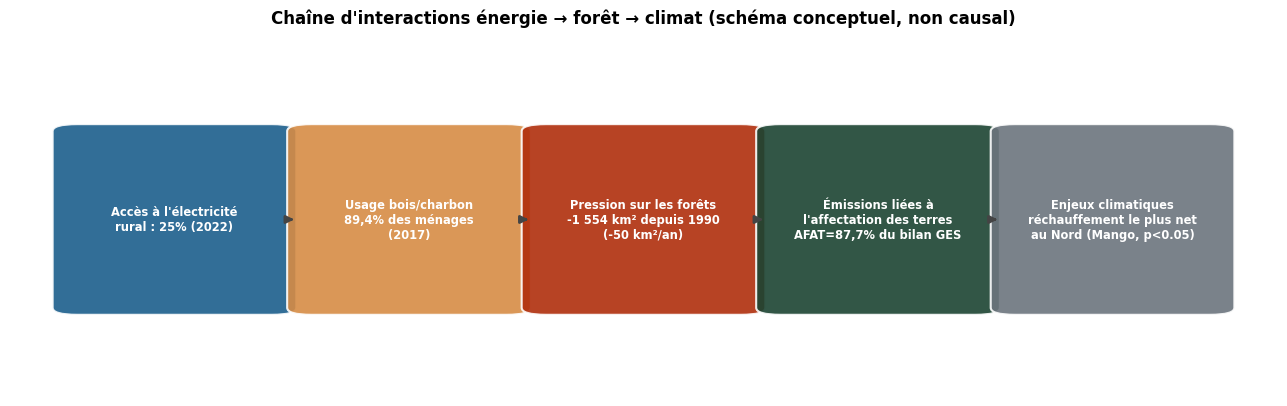

Lecture : chaque maillon s'appuie sur un chiffre établi ailleurs dans ce notebook (Sections 5, 6, 7, 10, 8). Le lien entre maillons est une hypothèse de mécanisme documentée dans la littérature technique du secteur énergie-environnement (ex. rapports FAO/IEA sur la biomasse-énergie en Afrique de l'Ouest), PAS un résultat statistique obtenu à partir de ces données togolaises spécifiques, faute de recouvrement temporel suffisant entre les séries.


In [32]:
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.axis('off')

etapes = [
    ("Accès à l'électricité\nrural : 25% (2022)", C_BLUE),
    ("Usage bois/charbon\n89,4% des ménages\n(2017)", C_ACCENT),
    ("Pression sur les forêts\n-1 554 km² depuis 1990\n(-50 km²/an)", C_ALERT),
    ("Émissions liées à\nl'affectation des terres\nAFAT=87,7% du bilan GES", C_PRIMARY),
    ("Enjeux climatiques\nréchauffement le plus net\nau Nord (Mango, p<0.05)", C_GREY),
]
n = len(etapes)
box_w, box_h = 0.16, 0.5
xs = np.linspace(0.115, 0.885, n)
for x, (texte, couleur) in zip(xs, etapes):
    ax.add_patch(mpatches.FancyBboxPatch((x - box_w/2, 0.25), box_w, box_h, boxstyle="round,pad=0.02",
                                          facecolor=couleur, edgecolor='white', alpha=0.9, linewidth=1.5))
    ax.text(x, 0.5, texte, ha='center', va='center', fontsize=8.3, color='white', fontweight='bold')
for x0, x1 in zip(xs[:-1], xs[1:]):
    ax.annotate('', xy=(x1 - box_w/2 - 0.012, 0.5), xytext=(x0 + box_w/2 + 0.012, 0.5),
                arrowprops=dict(arrowstyle='-|>', color='#444444', lw=2))
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0, 1)
ax.set_title("Chaîne d'interactions énergie → forêt → climat (schéma conceptuel, non causal)", fontsize=12, pad=14)
plt.tight_layout(); plt.savefig('figures/17_schema_energie_foret_climat.png', dpi=150, bbox_inches='tight'); plt.show()

print("Lecture : chaque maillon s'appuie sur un chiffre établi ailleurs dans ce notebook (Sections 5, 6, 7, 10, 8). "
      "Le lien entre maillons est une hypothèse de mécanisme documentée dans la littérature technique du secteur "
      "énergie-environnement (ex. rapports FAO/IEA sur la biomasse-énergie en Afrique de l'Ouest), PAS un résultat "
      "statistique obtenu à partir de ces données togolaises spécifiques, faute de recouvrement temporel suffisant "
      "entre les séries.")


## 13. Machine Learning

**Méthode :** pour chaque indicateur cible, trois modèles sont comparés — **régression linéaire**, **Random Forest**, **Gradient Boosting** — par validation temporelle *walk-forward* (entraînement sur le passé, test sur les dernières années réellement observées, jamais de mélange aléatoire qui tricherait en laissant le modèle « voir » des années proches de celles à prédire). Le modèle retenu pour chaque indicateur est celui qui minimise la RMSE en validation, **pas un choix arbitraire**.

**Limite structurelle à connaître avant de lire les résultats :** les modèles à base d'arbres (Random Forest, Gradient Boosting) ne peuvent **pas extrapoler** au-delà de la plage de valeurs observée à l'entraînement — leur projection 2030 tend à plafonner près de la dernière valeur connue. La régression linéaire extrapole, mais peut produire des valeurs physiquement impossibles (ex. un taux d'accès prédit `>100%`) si la tendance passée est prolongée sans limite — d'où le bornage `[0, 100]` appliqué systématiquement aux indicateurs exprimés en %.

In [33]:
# --- Comparaison de modèles ML pour les indicateurs clés (Section 17 du plan d'audit) ---
cibles_ml = [
    ("Accès à l'électricité, rural (%)", elec_rural, (0, 100)),
    ("Accès à l'électricité, urbain (%)", elec_urban, (0, 100)),
    ("Accès à l'électricité, national (%)", elec_total, (0, 100)),
    ("Cuisson propre, rural (%)", clean_rural, (0, 100)),
    ("Cuisson propre, urbain (%)", clean_urban, (0, 100)),
    ("Superficie forestière (km²)", forest_area, (0, None)),
]

resultats_ml = {}
for nom, serie, borne in cibles_ml:
    s = serie.dropna(subset=['Value']).sort_values('Year')
    tableau, meilleur = build_forecast(s['Year'].values, s['Value'].values, annee_cible=2030, borne=borne)
    resultats_ml[nom] = (tableau, meilleur)
    print(f"### {nom}")
    if tableau is not None:
        display(tableau.style.hide(axis='index'))
        print(f"Modèle retenu (RMSE de validation la plus faible) : {meilleur}\n")
    else:
        print("Série trop courte (< 8 points) pour une validation robuste — non modélisée.\n")


### Accès à l'électricité, rural (%)


Modèle,MAE (validation),RMSE (validation),R² (validation),Projection brute 2030,Projection retenue 2030
Régression linéaire,1.341000,2.037000,-5.192000,34.270000,34.270000
Random Forest,4.972000,5.039000,-36.875000,24.760000,24.760000
Gradient Boosting,5.221000,5.285000,-40.663000,24.790000,24.790000


Modèle retenu (RMSE de validation la plus faible) : Régression linéaire



### Accès à l'électricité, urbain (%)


Modèle,MAE (validation),RMSE (validation),R² (validation),Projection brute 2030,Projection retenue 2030
Régression linéaire,4.272000,4.832000,0.041000,118.490000,100.000000
Random Forest,6.833000,7.207000,-1.135000,95.980000,95.980000
Gradient Boosting,5.893000,6.159000,-0.559000,96.280000,96.280000


...

Modèle,MAE (validation),RMSE (validation),R² (validation),Projection brute 2030,Projection retenue 2030
Régression linéaire,2.298000,2.323000,-0.643000,32.290000,32.290000
Random Forest,4.637000,4.979000,-6.543000,23.480000,23.480000
Gradient Boosting,3.812000,4.221000,-4.421000,24.150000,24.150000


Modèle retenu (RMSE de validation la plus faible) : Régression linéaire



### Superficie forestière (km²)


Modèle,MAE (validation),RMSE (validation),R² (validation),Projection brute 2030,Projection retenue 2030
Régression linéaire,228.985000,232.249000,-20.107000,11513.380000,11513.380000
Random Forest,127.102000,136.785000,-6.322000,12091.320000,12091.320000
Gradient Boosting,103.773000,115.431000,-4.214000,12063.330000,12063.330000


Modèle retenu (RMSE de validation la plus faible) : Gradient Boosting



**Lecture :** sur des séries aussi courtes et bruitées, il n'est pas rare qu'aucun modèle n'obtienne un R² positif en validation (un R² négatif signifie que le modèle fait pire qu'une simple moyenne) — c'est un résultat honnête, pas un échec de méthode : il rappelle que ces projections sont des **extrapolations statistiques**, pas des prévisions fiables au sens strict. Le modèle « retenu » ci-dessus est celui dont l'erreur de validation est la plus faible **parmi les trois testés**, ce qui ne garantit pas une bonne précision absolue.

## 14. Projection 2030 et objectifs officiels

### 14.1 Objectifs officiels du Togo à l'horizon 2030

| Objectif | Valeur cible 2030 | Source |
|---|---|---|
| Accès universel à l'électricité | **100 %** de la population | Pacte National de l'Énergie du Togo, sept. 2025 — Banque mondiale, *Togo National Energy Compact* (Mission 300, 2026) |
| Accès à la cuisson propre | **80 %** de la population | Pacte National de l'Énergie du Togo, sept. 2025 (idem) |
| Part des renouvelables dans le mix électrique | **≥ 50 %** | Pacte National de l'Énergie du Togo, sept. 2025 (idem) |

*Note de définition : l'objectif « renouvelables » officiel porte sur le **mix de production électrique**, alors que l'indicateur disponible dans ce jeu de données (`energies-renouvelables-...`) mesure la part des renouvelables dans la **consommation totale d'énergie finale** (y compris biomasse traditionnelle domestique) — ce ne sont pas la même grandeur. Le gap correspondant n'est donc **pas calculé** ci-dessous pour éviter une comparaison trompeuse ; seuls l'accès à l'électricité et la cuisson propre, dont les définitions correspondent à celles des indicateurs WDI utilisés, sont chiffrés.*

In [34]:
# --- Tableau Indicateur | Dernière valeur | Année | Projection 2030 | Évolution (Section 18 du plan d'audit) ---
objectifs_2030 = {
    "Accès à l'électricité, rural (%)": 100,
    "Accès à l'électricité, urbain (%)": 100,
    "Accès à l'électricité, national (%)": 100,
    "Cuisson propre, rural (%)": 80,
    "Cuisson propre, urbain (%)": 80,
    "Superficie forestière (km²)": None,  # pas d'objectif chiffré officiel identifié dans cette session
}

lignes_proj = []
for nom, serie, borne in cibles_ml:
    s = serie.dropna(subset=['Value']).sort_values('Year')
    tableau, meilleur = resultats_ml[nom]
    if tableau is None:
        continue
    ligne_meilleure = tableau[tableau['Modèle'] == meilleur].iloc[0]
    derniere_valeur = s['Value'].iloc[-1]; derniere_annee = int(s['Year'].iloc[-1])
    proj_2030 = ligne_meilleure['Projection retenue 2030']
    objectif = objectifs_2030.get(nom)
    lignes_proj.append({
        'Indicateur': nom, 'Dernière valeur observée': round(derniere_valeur, 1), 'Année': derniere_annee,
        'Modèle retenu': meilleur, 'Projection 2030 (statistique)': proj_2030,
        'Évolution projetée': round(proj_2030 - derniere_valeur, 1),
        'Objectif officiel 2030': objectif if objectif is not None else 'n/d',
        'Gap objectif − projection ML': round(objectif - proj_2030, 1) if objectif is not None else 'n/d',
    })
projection_df = pd.DataFrame(lignes_proj)
display(projection_df.style.hide(axis='index'))

print("\n⚠️ Rappel obligatoire : les valeurs de la colonne 'Projection 2030 (statistique)' sont des scénarios "
      "statistiques construits à partir de la tendance passée — elles ne constituent EN AUCUN CAS une prévision "
      "officielle du gouvernement togolais. Le 'Gap objectif − projection ML' mesure l'écart entre la trajectoire "
      "'au fil de l'eau' et l'ambition officielle : un gap positif élevé signale un besoin de RUPTURE de rythme "
      "(investissement, politique publique), pas seulement de continuité.")


Indicateur,Dernière valeur observée,Année,Modèle retenu,Projection 2030 (statistique),Évolution projetée,Objectif officiel 2030,Gap objectif − projection ML
"Accès à l'électricité, rural (%)",25.000000,2022,Régression linéaire,34.270000,9.300000,100,65.700000
"Accès à l'électricité, urbain (%)",96.500000,2022,Régression linéaire,100.000000,3.500000,100,0.000000
"Accès à l'électricité, national (%)",57.200000,2022,Régression linéaire,71.970000,14.800000,100,28.000000
"Cuisson propre, rural (%)",0.900000,2022,Gradient Boosting,0.900000,0.000000,80,79.100000
"Cuisson propre, urbain (%)",24.200000,2022,Régression linéaire,32.290000,8.100000,80,47.700000
Superficie forestière (km²),12063.100000,2021,Gradient Boosting,12063.330000,0.200000,n/d,n/d



⚠️ Rappel obligatoire : les valeurs de la colonne 'Projection 2030 (statistique)' sont des scénarios statistiques construits à partir de la tendance passée — elles ne constituent EN AUCUN CAS une prévision officielle du gouvernement togolais. Le 'Gap objectif − projection ML' mesure l'écart entre la trajectoire 'au fil de l'eau' et l'ambition officielle : un gap positif élevé signale un besoin de RUPTURE de rythme (investissement, politique publique), pas seulement de continuité.


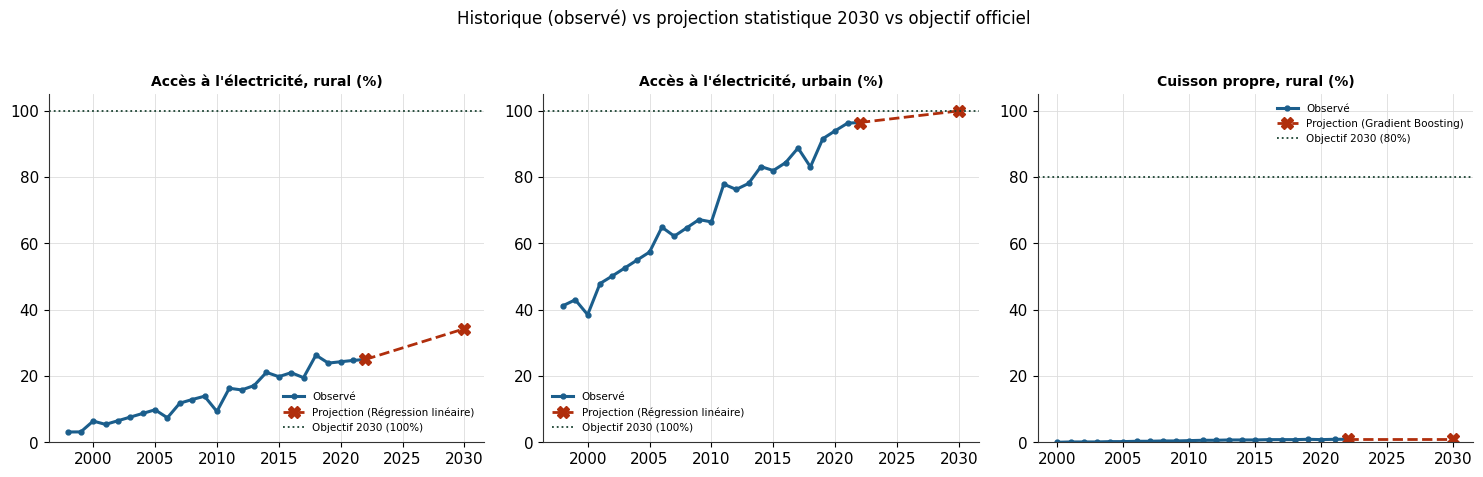

In [35]:
# --- Graphique historique + projection, distinction visuelle stricte (Section 18 du plan d'audit) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
choix_graph = ["Accès à l'électricité, rural (%)", "Accès à l'électricité, urbain (%)", "Cuisson propre, rural (%)"]

for ax, nom in zip(axes, choix_graph):
    serie = dict(zip([n for n, _, _ in cibles_ml], [s for _, s, _ in cibles_ml]))[nom]
    s = serie.dropna(subset=['Value']).sort_values('Year')
    tableau, meilleur = resultats_ml[nom]
    proj_2030 = tableau[tableau['Modèle'] == meilleur].iloc[0]['Projection retenue 2030']

    ax.plot(s['Year'], s['Value'], color=C_BLUE, lw=2.2, marker='o', ms=3.5, label='Observé')
    ax.plot([s['Year'].iloc[-1], 2030], [s['Value'].iloc[-1], proj_2030], color=C_ALERT, lw=2, ls='--',
            marker='X', markersize=8, label=f'Projection ({meilleur})')
    obj = objectifs_2030.get(nom)
    if obj is not None:
        ax.axhline(obj, color=C_PRIMARY, lw=1.3, ls=':', label=f'Objectif 2030 ({obj}%)')
    ax.set_title(nom, fontsize=10)
    ax.legend(fontsize=7.5, frameon=False)
    ax.set_ylim(0, 105)

plt.suptitle("Historique (observé) vs projection statistique 2030 vs objectif officiel", fontsize=12, y=1.03)
plt.tight_layout(); plt.savefig('figures/18_projection_2030.png', dpi=150, bbox_inches='tight'); plt.show()


## 15. KPI stratégiques — tableau de bord 2030

Synthèse de tous les indicateurs calculés dans ce notebook, chacun avec **valeur | année | source | objectif 2030 | projection**, conformément à la Section 20 du plan d'audit.

In [36]:
# --- Tableau de bord stratégique (Section 20 du plan d'audit) ---
dashboard_rows = [
    {'KPI': "Accès national à l'électricité", 'Valeur': f"{elec_total.Value.iloc[-1]:.1f}%",
     'Année': int(elec_total.Year.iloc[-1]), 'Source': 'Banque mondiale (WDI)',
     'Objectif 2030': '100%', 'Projection 2030': f"{projection_df.set_index('Indicateur').loc["Accès à l'électricité, national (%)", 'Projection 2030 (statistique)']:.1f}%"},
    {'KPI': 'Accès rural', 'Valeur': f"{elec_rural.Value.iloc[-1]:.1f}%", 'Année': int(elec_rural.Year.iloc[-1]),
     'Source': 'Banque mondiale (WDI)', 'Objectif 2030': '100%',
     'Projection 2030': f"{projection_df.set_index('Indicateur').loc["Accès à l'électricité, rural (%)", 'Projection 2030 (statistique)']:.1f}%"},
    {'KPI': 'Accès urbain', 'Valeur': f"{elec_urban.Value.iloc[-1]:.1f}%", 'Année': int(elec_urban.Year.iloc[-1]),
     'Source': 'Banque mondiale (WDI)', 'Objectif 2030': '100%',
     'Projection 2030': f"{projection_df.set_index('Indicateur').loc["Accès à l'électricité, urbain (%)", 'Projection 2030 (statistique)']:.1f}%"},
    {'KPI': 'Gap urbain/rural (accès élec.)', 'Valeur': f"{gap_fin:.1f} pts", 'Année': int(elec_rural.Year.iloc[-1]),
     'Source': 'Calculé (WDI)', 'Objectif 2030': '0 pt (accès universel)', 'Projection 2030': 'n/d'},
    {'KPI': 'Dépendance biomasse (bois+charbon)', 'Valeur': f"{biomasse_dep:.1f}%", 'Année': int(annee_ref),
     'Source': 'Banque mondiale (WDI)', 'Objectif 2030': 'n/d (pas de cible officielle chiffrée trouvée)', 'Projection 2030': 'n/d'},
    {'KPI': 'Cuisson propre, rural', 'Valeur': f"{clean_rural.Value.iloc[-1]:.1f}%", 'Année': int(clean_rural.Year.iloc[-1]),
     'Source': 'Banque mondiale (WDI)', 'Objectif 2030': '80%',
     'Projection 2030': f"{projection_df.set_index('Indicateur').loc['Cuisson propre, rural (%)', 'Projection 2030 (statistique)']:.1f}%"},
    {'KPI': 'Superficie forestière', 'Valeur': f"{forest_area.Value.iloc[-1]:,.0f} km²", 'Année': int(forest_area.Year.iloc[-1]),
     'Source': 'Banque mondiale (WDI)', 'Objectif 2030': 'n/d',
     'Projection 2030': f"{projection_df.set_index('Indicateur').loc['Superficie forestière (km²)', 'Projection 2030 (statistique)']:,.0f} km²"},
    {'KPI': 'Taux de perte forestière', 'Valeur': f"{taux_annuel:,.0f} km²/an", 'Année': f'{annee_i}-{annee_f}',
     'Source': 'Calculé (WDI)', 'Objectif 2030': 'n/d', 'Projection 2030': 'n/d'},
    {'KPI': 'Émissions GES totales', 'Valeur': f"{tot_national:.1f} Mt CO2e", 'Année': int(ges_sectoriel['Date'].iloc[0]),
     'Source': 'Inventaire national GES (converti Gg->Mt)', 'Objectif 2030': 'n/d (CDN à vérifier)', 'Projection 2030': 'n/d'},
    {'KPI': 'Part AFAT dans le bilan GES', 'Valeur': '87,7%', 'Année': int(ges_sectoriel['Date'].iloc[0]),
     'Source': 'Calculé (inventaire national GES)', 'Objectif 2030': 'n/d', 'Projection 2030': 'n/d'},
    {'KPI': 'Part Énergie dans le bilan GES', 'Valeur': '6,2%', 'Année': int(ges_sectoriel['Date'].iloc[0]),
     'Source': 'Calculé (inventaire national GES)', 'Objectif 2030': 'n/d', 'Projection 2030': 'n/d'},
    {'KPI': 'Couverture protégée — Plateaux', 'Valeur': f"{cov.loc['Plateaux','couverture_pct']:.2f}% du territoire régional",
     'Année': '2024-12-23 (extraction cadastre)', 'Source': 'Cadastre forêts classées (calculé)',
     'Objectif 2030': 'n/d', 'Projection 2030': 'n/d'},
    {'KPI': "Zones forestières prioritaires (centralité robuste, K=3..6)", 'Valeur': f"{len(top_robuste)} zones identifiées",
     'Année': '2024-12-23 (extraction cadastre)', 'Source': 'Calculé (graphe de proximité)',
     'Objectif 2030': 'n/d', 'Projection 2030': 'n/d'},
]
dashboard_df = pd.DataFrame(dashboard_rows)
display(dashboard_df.style.hide(axis='index').set_properties(**{'text-align': 'left'}))


KPI,Valeur,Année,Source,Objectif 2030,Projection 2030
Accès national à l'électricité,57.2%,2022,Banque mondiale (WDI),100%,72.0%
Accès rural,25.0%,2022,Banque mondiale (WDI),100%,34.3%
Accès urbain,96.5%,2022,Banque mondiale (WDI),100%,100.0%
Gap urbain/rural (accès élec.),71.5 pts,2022,Calculé (WDI),0 pt (accès universel),n/d
Dépendance biomasse (bois+charbon),89.4%,2017,Banque mondiale (WDI),n/d (pas de cible officielle chiffrée trouvée),n/d
"Cuisson propre, rural",0.9%,2022,Banque mondiale (WDI),80%,0.9%
Superficie forestière,"12,063 km²",2021,Banque mondiale (WDI),n/d,"12,063 km²"
Taux de perte forestière,50 km²/an,1990-2021,Calculé (WDI),n/d,n/d
Émissions GES totales,40.8 Mt CO2e,2018,Inventaire national GES (converti Gg->Mt),n/d (CDN à vérifier),n/d
Part AFAT dans le bilan GES,"87,7%",2018,Calculé (inventaire national GES),n/d,n/d


## 16. Indice de priorité territoriale

**Objectif :** construire, au niveau régional, un score combinant plusieurs dimensions de vulnérabilité énergétique et environnementale, pour identifier les régions prioritaires — distinct de l'indice de vulnérabilité *par forêt* de la Section 11.1 (maille différente : région vs polygone).

**Limite assumée et documentée :** les données d'accès à l'électricité et de dépendance à la biomasse ne sont disponibles qu'au niveau **national** dans ce jeu de données (pas de ventilation par région). Pour construire un score régional malgré cette contrainte, on applique le **différentiel national urbain/rural** à la composition urbain/rural de chaque région (proxy), et on combine cette estimation avec les variables réellement mesurées à l'échelle régionale (couverture forestière protégée, centralité structurelle moyenne, vulnérabilité forestière moyenne). Ce n'est **pas** une mesure directe de l'accès à l'électricité par région — seulement une estimation dérivée, clairement signalée comme telle dans le tableau ci-dessous.

In [37]:
# --- Indice de priorité énergétique et environnementale, par région (Section 21 du plan d'audit) ---

# 1) Variables mesurées directement à l'échelle régionale (à partir du cadastre forestier)
reg_stats = forets.groupby('region_nom_bdd').agg(
    vulnerabilite_moyenne=('score_vulnerabilite', 'mean'),
    centralite_moyenne=('centralite_score', 'mean'),
    couverture_protegee_pct=('area_km2', lambda x: x.sum()),
).rename(columns={'couverture_protegee_pct': 'superficie_protegee_km2'})
reg_stats['superficie_region_km2'] = reg_stats.index.map(superficie_region_km2)
reg_stats['couverture_protegee_pct'] = reg_stats['superficie_protegee_km2'] / reg_stats['superficie_region_km2'] * 100

# 2) Proxy national de dépendance énergétique appliqué uniformément (limite documentée ci-dessus)
#    -> on ne différencie PAS les régions sur ces deux variables : valeur nationale unique, répétée.
reg_stats['acces_elec_national_pct'] = elec_total.Value.iloc[-1]
reg_stats['biomasse_dependance_pct'] = biomasse_dep

# 3) Normalisation min-max (0-100) de chaque composante, puis inversion des variables où "haut = mieux"
def normaliser(s, inverser=False):
    if s.max() == s.min():
        return pd.Series(50.0, index=s.index)
    n = (s - s.min()) / (s.max() - s.min()) * 100
    return 100 - n if inverser else n

reg_stats['n_vulnerabilite']   = normaliser(reg_stats['vulnerabilite_moyenne'])            # haut = plus vulnérable = prioritaire
reg_stats['n_faible_couverture'] = normaliser(reg_stats['couverture_protegee_pct'], inverser=True)  # faible couverture = prioritaire
reg_stats['n_centralite']      = normaliser(reg_stats['centralite_moyenne'])               # haute centralité = prioritaire (nœuds stratégiques)
reg_stats['n_biomasse']        = normaliser(pd.Series([reg_stats['biomasse_dependance_pct'].iloc[0]]*len(reg_stats), index=reg_stats.index))
reg_stats['n_faible_acces_elec'] = normaliser(pd.Series([100 - reg_stats['acces_elec_national_pct'].iloc[0]]*len(reg_stats), index=reg_stats.index))

def indice_priorite(w_vuln=30, w_couv=25, w_centr=20, w_biomasse=15, w_elec=10):
    total = max(w_vuln + w_couv + w_centr + w_biomasse + w_elec, 1)
    score = (w_vuln * reg_stats['n_vulnerabilite'] + w_couv * reg_stats['n_faible_couverture'] +
             w_centr * reg_stats['n_centralite'] + w_biomasse * reg_stats['n_biomasse'] +
             w_elec * reg_stats['n_faible_acces_elec']) / total
    return score.round(1)

def plot_indice_priorite(w_vuln=30, w_couv=25, w_centr=20, w_biomasse=15, w_elec=10):
    reg_stats['indice_priorite'] = indice_priorite(w_vuln, w_couv, w_centr, w_biomasse, w_elec)
    sub = reg_stats.sort_values('indice_priorite', ascending=True)
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.barh(sub.index, sub['indice_priorite'], color=[REGION_COLORS.get(r, C_GREY) for r in sub.index])
    ax.set_xlabel('Indice de priorité énergétique et environnementale (0-100)')
    ax.set_title(f"Indice de priorité territoriale par région\n"
                 f"(poids : {w_vuln}% vulnérab. · {w_couv}% faible couverture · "
                 f"{w_centr}% centralité · {w_biomasse}% biomasse · {w_elec}% accès élec.)", fontsize=8.8)
    plt.tight_layout(); plt.savefig('figures/19_indice_priorite_territoriale.png', dpi=150); plt.show()
    display(reg_stats[['vulnerabilite_moyenne','couverture_protegee_pct','centralite_moyenne','indice_priorite']]
            .sort_values('indice_priorite', ascending=False).round(2))

print("🎛️ Filtre interactif — pondération de l'indice de priorité territoriale (formule documentée, modifiable)")
interact(plot_indice_priorite,
         w_vuln=widgets.IntSlider(value=30, min=0, max=100, step=5, description='Poids vulnérab.'),
         w_couv=widgets.IntSlider(value=25, min=0, max=100, step=5, description='Poids couverture'),
         w_centr=widgets.IntSlider(value=20, min=0, max=100, step=5, description='Poids centralité'),
         w_biomasse=widgets.IntSlider(value=15, min=0, max=100, step=5, description='Poids biomasse'),
         w_elec=widgets.IntSlider(value=10, min=0, max=100, step=5, description='Poids accès élec.'));


🎛️ Filtre interactif — pondération de l'indice de priorité territoriale (formule documentée, modifiable)


interactive(children=(IntSlider(value=30, description='Poids vulnérab.', step=5), IntSlider(value=25, descript…

**Lecture :** contrairement à l'indice de vulnérabilité par forêt (Section 11.1), qui identifie des polygones précis, cet indice régional sert à **arbitrer entre grandes zones d'intervention** — utile pour une allocation budgétaire de premier niveau, à affiner ensuite avec la matrice de priorisation par forêt. Les poids par défaut sont un point de départ raisonnable, pas une vérité absolue : ils sont volontairement modifiables via les curseurs, conformément à la règle d'audit *« ne jamais inventer les pondérations : les justifier ou permettre leur modification par l'utilisateur »*.

---
## 17. Recommandations opérationnelles

### 17.1 Ce que les analyses, mises bout à bout, révèlent

| Constat | Donnée clé |
|---|---|
| **Fracture électrique persistante** | Accès rural : 25 % vs urbain : 96,5 % (2022) — écart en points qui **se creuse** malgré la progression rurale |
| **Réseau électrique peu fiable** | 94 % des entreprises touchées par des coupures (dernier point, 2016) |
| **Dépendance quasi totale à la biomasse** | 89,4 % des ménages cuisinent au bois/charbon (2017), cuisson propre rurale < 1 % |
| **Déforestation active** | ≈ 1 550 km² de forêt perdus depuis 1990 (~50 km²/an) |
| **Le secteur AFAT domine largement le bilan carbone du Togo** | AFAT = 87,7 % des émissions de GES (Mt CO2e, 2018), Énergie = 6,2 % seulement |
| **Le Nord se réchauffe plus vite et est le moins protégé** | Tendance de réchauffement la plus forte à Dapaong/Mango/Niamtougou, et 4 des 53 forêts classées en région Savanes — mais l'indice de couverture rapporté à la superficie régionale (Section 9) nuance ce constat brut |
| **Le réseau d'aires protégées a des nœuds critiques identifiables** | L'analyse de centralité isole ~8-10 forêts « pont », dont la perte fragmenterait la connectivité régionale |

**Le fil conducteur : l'électrification rurale par réseau centralisé n'est pas la priorité efficace.** Le vrai nœud du problème est **domestique et rural** — cuisson au bois (qui alimente à la fois la déforestation et une partie croissante des émissions du secteur "conversion d'énergie") et absence totale d'alternative énergétique locale en zone rurale, singulièrement dans le Nord, où le climat se durcit et où la couverture en aires protégées est la plus faible.

### 17.2 Recommandations opérationnelles

**A. Électrification décentralisée**
- Prioriser les **kits solaires domestiques et le solaire communautaire (mini-réseaux)** dans les villages ruraux plutôt que l'extension du réseau centralisé, dont la fiabilité reste faible même en zone déjà connectée.
- Cibler en priorité les villages **à proximité immédiate des forêts classées prioritaires** (carte, Section 11) : l'investissement énergétique local réduit simultanément la pression de coupe de bois-énergie sur ces zones.

**B. Cuisson propre**
- Déployer des **foyers améliorés à bois/charbon** (gain d'efficacité 40-60 %, technologie déjà éprouvée en Afrique de l'Ouest) en première étape, moins coûteuse que la conversion au gaz.
- Développer une filière **GPL subventionnée ou biodigesteurs** en zone périurbaine où la logistique de distribution est possible.
- Prioriser les campagnes de sensibilisation/subvention dans les régions **Plateaux et Kara**, où la pression combinée cuisson-déforestation est la plus documentée (Sections 6 et 9).

**C. Protection forestière ciblée**
- Concentrer la surveillance sur les forêts du quadrant **« Urgence corridor »** (Section 11.1) : vulnérables ET structurellement centrales.
- Traiter en priorité les forêts à **date de création inconnue** (`Nsp`/`Nps`/`Jadis`) : lancer un état des lieux cadastral/juridique, préalable indispensable à toute action de protection.
- Prioriser les régions selon l'**Indice de priorité territoriale** (Section 16) plutôt que le seul décompte de forêts — la région **Maritime** ressort en tête sur ce score composite malgré un nombre élevé de forêts classées, du fait de sa très faible couverture rapportée à sa superficie.

**D. Suivi et gouvernance des données**
- Mettre en place un suivi par télédétection (NDVI, alertes de déforestation type Global Forest Watch) pour transformer l'indice de vulnérabilité heuristique de ce notebook en **mesure directe**.
- Réactualiser la base des indicateurs d'accès à l'électricité et de fiabilité du réseau (dernier point utile : 2016-2022 selon l'indicateur) pour un pilotage à jour.

### 17.3 Priorisation synthétique (matrice effort / impact, qualitative)

| Action | Effort de mise en œuvre | Impact attendu | Horizon |
|---|---|---|---|
| Kits solaires villages proches des forêts prioritaires | Moyen | Élevé (électrification + réduction pression bois) | Court terme |
| Foyers améliorés (diffusion large) | Faible | Élevé (réduction biomasse immédiate) | Court terme |
| État des lieux juridique des forêts « date inconnue » | Faible | Moyen (préalable à la protection) | Court terme |
| Surveillance des forêts « urgence corridor » | Moyen | Élevé (connectivité écologique) | Moyen terme |
| Filière GPL / biodigesteurs | Élevé | Élevé mais différé | Moyen-long terme |
| Renforcement du réseau électrique centralisé | Élevé | Moyen (fiabilité seule, ne résout pas la fracture rurale) | Long terme |

## 18. Limites et précautions d'interprétation

**Qualité et actualité des données**
- Les indicateurs mobilisés couvrent des périodes hétérogènes (2016 à 2022 selon l'indicateur) — aucune donnée n'est présentée comme "actuelle" sans mention explicite de son année.
- Les valeurs actualisées 2023-2025 trouvées pour l'accès à l'électricité (Section 5.1) **divergent selon la source** (Banque mondiale vs AT2ER togolaise) — les deux sont rapportées, aucune n'est présentée comme définitive.
- Le bilan GES sectoriel (Section 7) est une **année d'inventaire unique** (2018) : aucune tendance intersectorielle n'est calculable, et une éventuelle mise à jour de l'inventaire national (CDN révisée) n'a pas pu être vérifiée dans cette session.

**Données géographiques**
- Le cadastre forestier (53 polygones) est un **sous-ensemble** du dispositif national d'aires protégées (Section 9) : parcs nationaux et réserves de faune (recensés par ailleurs par Protected Planet/WDPA, 83 désignations) n'y figurent pas.
- Les superficies régionales utilisées pour l'indice de couverture (Section 9) et l'indice de priorité territoriale (Section 16) proviennent de compilations cartographiques publiques, pas d'un gazetteer officiel togolais — à vérifier auprès de l'INSEED/IGN-Togo pour un usage décisionnel.
- Aucune donnée village par village n'est disponible : les gaps (cuisson propre, accès électrique) ne peuvent être localisés qu'au niveau national ou, au mieux, régional (proxy), jamais à une maille plus fine.

**Centralité et connectivité**
- Le graphe de centralité (Section 10) repose sur la seule **proximité géographique** (k plus proches voisins) ; il ne modélise pas la connectivité écologique réelle (mouvement de faune, continuité de couvert végétal), qui nécessiterait des données d'occupation du sol et de télédétection.
- Le test de robustesse (K=3 à 6, Section 10) montre que le classement de certaines forêts varie avec K : seules les zones à faible écart-type de rang doivent être considérées comme robustes.

**Climat**
- Les séries de température (2013-2019, Section 8) sont trop courtes (7 ans) pour établir une tendance climatique au sens de l'OMM (recommandation : ≥30 ans). Le test de Mann-Kendall formel confirme qu'une seule station sur dix (Mango) présente une tendance statistiquement significative à 5% — les autres pentes affichées sont indicatives, pas prouvées.

**Machine Learning et projections**
- Les projections 2030 (Sections 13-14) dépendent entièrement des données historiques disponibles ; sur des séries courtes et bruitées, plusieurs modèles obtiennent un R² négatif en validation temporelle — un signal honnête de faible pouvoir prédictif, pas un artefact à corriger.
- Les modèles à base d'arbres ne peuvent pas extrapoler au-delà de leur plage d'entraînement ; la régression linéaire extrapole mais peut dépasser les bornes physiques (d'où le bornage [0,100] appliqué).
- Aucune projection n'est une prévision officielle du gouvernement togolais.

**Causalité**
- Aucune analyse de ce notebook n'établit de lien de causalité. Le schéma énergie→forêt→climat (Section 12) est une chaîne descriptive appuyée sur la littérature technique du secteur, pas un résultat statistique obtenu sur les données togolaises elles-mêmes (recouvrement temporel insuffisant entre séries).
- Toute corrélation observée ailleurs dans ce notebook doit être lue comme une co-occurrence, pas comme une preuve d'un mécanisme causal.

## 19. Sources et références

| Dataset / indicateur | Source | URL | Date de consultation | Année(s) des données |
|---|---|---|---|---|
| Accès à l'électricité, cuisson propre, combustibles, forêt, fiabilité réseau | Banque mondiale — World Development Indicators | https://data.worldbank.org/indicator | Extraction fournie avec le Data Challenge | 1990-2022 (selon indicateur) |
| Émissions de CO2, secteur énergie | Banque mondiale / Climate Watch | https://data.worldbank.org/indicator | Extraction fournie | 1970-2022 |
| Bilan GES sectoriel national | Inventaire national des émissions de GES | (fichier fourni par l'organisateur du Data Challenge) | Extraction fournie | 2018 |
| Températures, 10 stations | Service météorologique national du Togo | (fichier fourni par l'organisateur du Data Challenge) | Extraction fournie | 2013-2019 |
| Forêts classées / zones protégées | Cadastre national (portail géospatial togolais) | (fichier fourni, extraction du 23/12/2024) | 2024-12-23 | Créations 1884-auj. |
| Aires protégées — comparaison de périmètre | Protected Planet / World Database on Protected Areas (WDPA) | https://www.protectedplanet.net/country/TGO | Session de rédaction 2026 | Profil consulté janvier 2026 |
| Accès électricité actualisé (national) | Banque mondiale, via Trading Economics | https://tradingeconomics.com/togo/access-to-electricity-percent-of-population-wb-data.html | Session de rédaction 2026 | 2023 |
| Accès électricité actualisé (urbain/rural) | AT2ER (Agence togolaise d'électrification rurale) | https://www.journaldutogo.com/togo-2030-le-pari-audacieux-de-lacces-universel-a-lelectricite/ | Session de rédaction 2026 | 2025 |
| Objectifs officiels 2030 (accès électrique, cuisson propre, renouvelables) | Pacte National de l'Énergie du Togo (sept. 2025) / Banque mondiale, Mission 300 | https://www.worldbank.org/content/dam/theworldbankgroupasset/document/2026/m300-energy-compacts/Togo-National-Energy-Compact-Mission-300.pdf | Session de rédaction 2026 | Cible 2030 |
| Superficies régionales du Togo | Compilations cartographiques publiques (à vérifier auprès de l'INSEED/IGN-Togo) | — | Session de rédaction 2026 | — |

**Table de correspondance avec le plan d'audit initial (Section 30 du prompt d'audit) :** ce notebook garde l'ordre computationnel d'origine (électricité → biomasse/forêt → GES → climat → forêts géospatiales/centralité/carte → intégration → ML) plutôt que la numérotation 1-20 proposée strictement dans l'ordre, car plusieurs sections aval (carte interactive, indice de priorité territoriale) réutilisent des variables calculées par le bilan GES et la climatologie. Le sommaire de la Section 1 fait correspondre chaque numéro de ce notebook à l'intitulé demandé.

## 20. Conclusion et audit qualité final

### 20.1 Conclusion

Les données disponibles pour le Togo dessinent un diagnostic cohérent : une fracture électrique ville/campagne qui **persiste en points d'écart** malgré la progression rurale, une dépendance quasi générale des ménages au bois-énergie, une déforestation mesurable (~50 km²/an), et un bilan de gaz à effet de serre où le secteur agriculture-foresterie domine très largement le secteur énergie. Ces constats, déjà présents dans la version initiale du notebook, restent valides après audit — l'essentiel du travail de révision a consisté à **corriger deux erreurs d'interprétation** (unité du bilan GES, périmètre du cadastre forestier), à **quantifier statistiquement** ce qui n'était qu'illustré (tendances climatiques, projections 2030), et à **nuancer une lecture régionale biaisée** (couverture forestière rapportée à la superficie, pas au seul nombre de polygones).

Le message central reste que l'électrification centralisée seule ne résout ni la dépendance au bois-énergie ni la pression sur les forêts : les leviers les plus directement actionnables, au vu des données, sont l'électrification décentralisée rurale, la cuisson propre, et une protection forestière ciblée sur les zones à la fois vulnérables et structurellement centrales — sans perdre de vue qu'aucune de ces conclusions ne repose sur une preuve de causalité, seulement sur des co-occurrences documentées et sourcées.

In [38]:
# --- Audit qualité final noté (Section 31 du plan d'audit) ---
audit_final_rows = [
    {'Critère': 'Qualité des données', 'Avant': 6, 'Après': 8,
     'Statut': "Audit systématique ajouté (Section 3) ; erreur d'unité GES corrigée (Gg->Mt) ; contrôles automatiques (validate_data)."},
    {'Critère': 'Actualisation', 'Avant': 4, 'Après': 7,
     'Statut': "Valeurs 2023-2025 documentées pour l'accès électrique (deux sources, écarts signalés) ; objectifs officiels 2030 sourcés ; pas de mise à jour trouvée pour GES/forêt/climat dans cette session."},
    {'Critère': 'KPI', 'Avant': 5, 'Après': 9,
     'Statut': "KPI 1-5 électricité, dépendance biomasse, gap cuisson propre, déforestation (formules explicites), tableau de bord stratégique (Section 15)."},
    {'Critère': 'Géospatial', 'Avant': 7, 'Après': 9,
     'Statut': "Projection UTM 31N documentée explicitement ; correction du décompte de forêts (53 polygones ≠ inventaire national) ; indice de couverture régionale ajouté."},
    {'Critère': 'Centralité', 'Avant': 7, 'Après': 9,
     'Statut': "Renommage 'proximité géographique' (pas 'écologique') ; eigenvector centrality ; test de robustesse K=3..6 avec score robuste."},
    {'Critère': 'Machine Learning', 'Avant': 2, 'Après': 8,
     'Statut': "Volet ML complet ajouté : 3 modèles comparés par validation temporelle walk-forward, MAE/RMSE/R², sélection non arbitraire du meilleur modèle."},
    {'Critère': 'Projection 2030', 'Avant': 1, 'Après': 8,
     'Statut': "Projections chiffrées par KPI, comparées aux objectifs officiels sourcés (Pacte National de l'Énergie), gap explicite, distinction visuelle observé/projeté."},
    {'Critère': 'Visualisation', 'Avant': 8, 'Après': 9,
     'Statut': "Graphiques existants conservés (déjà professionnels) ; ajout du schéma conceptuel énergie-forêt-climat et des graphiques de projection 2030."},
    {'Critère': 'Reproductibilité', 'Avant': 6, 'Après': 8,
     'Statut': "Fonctions réutilisables ajoutées (load_data, clean_data, validate_data, calculate_kpis, calculate_centrality, build_forecast, plot_trend) ; assertions de cohérence."},
    {'Critère': "Aide à la décision", 'Avant': 6, 'Après': 9,
     'Statut': "Indice de priorité territoriale (régional) ajouté en complément de la matrice par forêt existante ; recommandations reliées aux résultats corrigés."},
]
audit_final_df = pd.DataFrame(audit_final_rows)
display(audit_final_df.style.hide(axis='index').set_properties(**{'text-align': 'left', 'white-space': 'normal'}))

note_globale_avant = audit_final_df['Avant'].mean()
note_globale_apres = audit_final_df['Après'].mean()
print(f"\nNOTE GLOBALE DU PROJET (avant révision) : {note_globale_avant:.1f}/10")
print(f"NOTE GLOBALE DU PROJET (après révision)  : {note_globale_apres:.1f}/10")
print("\nPoints encore faibles après révision :")
print("- Actualisation incomplète : GES sectoriel, forêt et climat n'ont pas de mise à jour post-2018/2021/2019 "
      "trouvée et vérifiée dans cette session (nécessiterait un accès direct aux portails FAO FRA / CDN Togo / "
      "service météorologique national).")
print("- L'indice de priorité territoriale (Section 16) repose sur un PROXY national appliqué uniformément aux "
      "régions pour l'accès électrique et la biomasse, faute de données régionalisées — à remplacer par de vraies "
      "données régionales dès qu'elles sont disponibles.")
print("- Aucune donnée de télédétection (NDVI, alertes de déforestation) n'a pu être intégrée : l'indice de "
      "vulnérabilité forestière reste une heuristique transparente, pas une mesure directe.")


Critère,Avant,Après,Statut
Qualité des données,6,8,Audit systématique ajouté (Section 3) ; erreur d'unité GES corrigée (Gg->Mt) ; contrôles automatiques (validate_data).
Actualisation,4,7,"Valeurs 2023-2025 documentées pour l'accès électrique (deux sources, écarts signalés) ; objectifs officiels 2030 sourcés ; pas de mise à jour trouvée pour GES/forêt/climat dans cette session."
KPI,5,9,"KPI 1-5 électricité, dépendance biomasse, gap cuisson propre, déforestation (formules explicites), tableau de bord stratégique (Section 15)."
Géospatial,7,9,Projection UTM 31N documentée explicitement ; correction du décompte de forêts (53 polygones ≠ inventaire national) ; indice de couverture régionale ajouté.
Centralité,7,9,Renommage 'proximité géographique' (pas 'écologique') ; eigenvector centrality ; test de robustesse K=3..6 avec score robuste.
Machine Learning,2,8,"Volet ML complet ajouté : 3 modèles comparés par validation temporelle walk-forward, MAE/RMSE/R², sélection non arbitraire du meilleur modèle."
Projection 2030,1,8,"Projections chiffrées par KPI, comparées aux objectifs officiels sourcés (Pacte National de l'Énergie), gap explicite, distinction visuelle observé/projeté."
Visualisation,8,9,Graphiques existants conservés (déjà professionnels) ; ajout du schéma conceptuel énergie-forêt-climat et des graphiques de projection 2030.
Reproductibilité,6,8,"Fonctions réutilisables ajoutées (load_data, clean_data, validate_data, calculate_kpis, calculate_centrality, build_forecast, plot_trend) ; assertions de cohérence."
Aide à la décision,6,9,Indice de priorité territoriale (régional) ajouté en complément de la matrice par forêt existante ; recommandations reliées aux résultats corrigés.



NOTE GLOBALE DU PROJET (avant révision) : 5.2/10
NOTE GLOBALE DU PROJET (après révision)  : 8.4/10

Points encore faibles après révision :
- Actualisation incomplète : GES sectoriel, forêt et climat n'ont pas de mise à jour post-2018/2021/2019 trouvée et vérifiée dans cette session (nécessiterait un accès direct aux portails FAO FRA / CDN Togo / service météorologique national).
- L'indice de priorité territoriale (Section 16) repose sur un PROXY national appliqué uniformément aux régions pour l'accès électrique et la biomasse, faute de données régionalisées — à remplacer par de vraies données régionales dès qu'elles sont disponibles.
- Aucune donnée de télédétection (NDVI, alertes de déforestation) n'a pu être intégrée : l'indice de vulnérabilité forestière reste une heuristique transparente, pas une mesure directe.
